# Housing Price Prediction using Multiple Linear Regression

## Overall Goals
The housing market plays a crucial role in the economy, with property prices significantly influencing investment decisions. As real estate data continues to grow, analyzing the factors that drive housing prices becomes increasingly important. This project aims to use multiple linear regression (MLR) to predict housing prices in King County, Washington, based on various property features. By analyzing a dataset from Kaggle, this project will identify key factors influencing high property values and develop a predictive model to aid real estate decision-making.

## Importing the libraries

In [54]:
# import packages
import numpy as np
import pandas as pd

# for Plotting
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from plotly.subplots import make_subplots
import plotly.graph_objects as go

# The purpose is to find the city where the house is located.
from uszipcode import SearchEngine

import warnings
warnings.filterwarnings("ignore")

# import geo pandas
import geopandas as gpd
from shapely.geometry import Point, Polygon

#for Train and Regression
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.feature_selection import f_regression

from sklearn.preprocessing import PolynomialFeatures
from mpl_toolkits.mplot3d import Axes3D

## Fetching/Reading Dataset
The objective of this report is to predict house sales in King County, Washington, USA, using Multiple Linear Regression (MLR). The dataset consists of historical sales data of houses sold between May 2014 and May 2015 in King County, which includes areas like Seattle. Our goal is to predict house prices with an accuracy of at least 75-80% and identify the key factors influencing properties with prices of $650K and above. The dataset, sourced from [Kaggle](https://www.kaggle.com/datasets/shivachandel/kc-house-data), includes 21 variables and 21,613 observations.

### Load the Data

In [3]:
df=pd.read_csv('kc_house_data.csv')
df.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180.0,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170.0,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770.0,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050.0,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680.0,0,1987,0,98074,47.6168,-122.045,1800,7503


### Fill Missing Values

In [4]:
# Check if there are any missing values in the dataset
df.isnull().any()

id               False
date             False
price            False
bedrooms         False
bathrooms        False
sqft_living      False
sqft_lot         False
floors           False
waterfront       False
view             False
condition        False
grade            False
sqft_above        True
sqft_basement    False
yr_built         False
yr_renovated     False
zipcode          False
lat              False
long             False
sqft_living15    False
sqft_lot15       False
dtype: bool

In [5]:
# Fill missing values in the 'sqft_above' column with the mean of that column
df['sqft_above'] = df['sqft_above'].fillna(df['sqft_above'].mean())
df.isnull().any().any()

False

## Data Cleaning & Exploratory Data Analysis
In this section, key features were selected for analysis based on their relevance and correlation with the target variable. For example, house size (in square feet) and the number of rooms are both significant factors. Larger homes typically have more rooms, suggesting a potential correlation between these variables. To address the risk of multicollinearity, we strategically chose variables that provide distinct and meaningful contributions to explaining the target variable, ensuring a robust and interpretable model.

This dataset contains information about house sales in King County, Washington, between May 2014 and May 2015. The features are as follows:

- **id**: Unique identifier for each house, used to distinguish individual properties.
- **date**: The sale date of the house, in the format `yyyyMMdd`. It indicates when the house was sold.
- **price**: The sale price of the house, in USD. For example, 221,900 USD.
- **bedrooms**: The number of bedrooms in the house.
- **bathrooms**: The number of bathrooms in the house.
- **sqft_living**: The living area of the house in square feet. This represents the usable interior space.
- **sqft_lot**: The total land area of the house, in square feet.
- **floors**: The number of floors in the house. For example, 1 for a single-story house, 2 for a two-story house.
- **waterfront**: Indicates whether the house is waterfront. `1` means it is on the waterfront, while `0` means it is not.
- **view**: The view quality rating of the house, typically ranging from 0 to 4. `0` means no view, and `4` indicates an excellent view.
- **condition**: The condition rating of the house, usually from 1 to 5, where `1` is the worst condition and `5` is the best.
- **grade**: The grade rating of the house, based on construction quality and design, typically ranging from 1 to 13. `13` represents the highest standard of construction.
- **sqft_above**: The above-ground living area, in square feet. This excludes the basement and includes all above-ground floors.
- **sqft_basement**: The basement area, in square feet. If the house does not have a basement, this value is typically `0`.
- **yr_built**: The year the house was built.
- **yr_renovated**: The year the house was last renovated. If not renovated, this value is `0`.
- **zipcode**: The postal code for the location of the house.
- **lat**: The latitude of the house, indicating its geographical location.
- **long**: The longitude of the house, indicating its geographical location.
- **sqft_living15**: The living area of the house in 2015, in square feet. This is used for analyzing changes in living space over time.
- **sqft_lot15**: The land area of the house in 2015, in square feet. This is used for analyzing changes in land area over time.

Now, let's try to analyze some factors that may affect the price.

### Building Age
House prices are influenced by building age, as newer homes are typically priced higher due to modern features and better condition, while older homes, despite needing repairs, may still command higher prices if located in desirable areas.

In [6]:
# Calculate the building age based on the 'yr_built' column, assuming 2015 is the reference year
df['building_age'] = 2015 - df['yr_built']

# Compute the average price for each building age
price_with_building_age = pd.DataFrame({
    'Building Age': sorted(df['building_age'].unique()), 
    'Price': df.groupby('building_age')['price'].mean()
})

# Plot a bar chart to show average house price for each building age
px.bar(price_with_building_age, x='Building Age', y='Price', color='Building Age', 
       title='Average House Price by Building Age')


<Axes: xlabel='building_age', ylabel='price'>

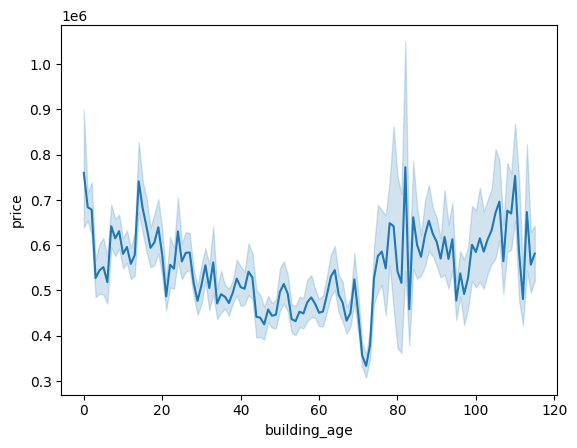

In [7]:
# Create a line plot to visualize the relationship between building age and house price
sns.lineplot(x='building_age', y='price', data=df)

### Grade
Grade is related to house price as higher-grade homes, which are built with better materials and design, typically command higher prices compared to lower-grade homes.

In [8]:
# Calculate the average house price for each grade
grade_price_df = df.groupby('grade')['price'].mean().reset_index()

# Creating a bar chart using Plotly Express
fig = px.bar(grade_price_df, 
             x='grade', 
             y='price', 
             color='grade', 
             title='Average House Price for Each House Grade',
             labels={'grade': 'House Grade', 'price': 'Average Price ($)'},
             color_continuous_scale='Viridis')

fig.show()

### Number of Bedrooms or Bathrooms
The number of bedrooms and bathrooms both impact house prices. Generally, more bedrooms and bathrooms correlate with higher prices, as larger homes with more amenities tend to be more expensive.

In [9]:
bedrooms_price_df = df.groupby('bedrooms')['price'].mean().reset_index()
bathrooms_price_df = df.groupby('bathrooms')['price'].mean().reset_index()

fig = make_subplots(rows=1, cols=2, subplot_titles=('Price vs. Bedrooms', 'Price vs. Bathrooms'))

# Add the Bedrooms plot (first subplot)
fig.add_trace(go.Bar(x=bedrooms_price_df['bedrooms'], 
                     y=bedrooms_price_df['price'], 
                     name='Bedrooms',
                     marker_color='blue'),
              row=1, col=1)

# Add the Bathrooms plot (second subplot)
fig.add_trace(go.Bar(x=bathrooms_price_df['bathrooms'], 
                     y=bathrooms_price_df['price'], 
                     name='Bathrooms',
                     marker_color='green'),
              row=1, col=2)

fig.update_layout(
    title='Average House Price for Each Number of Bedrooms and Bathrooms',
    xaxis_title='Number of Bedrooms',
    yaxis_title='Average Price ($)',
    xaxis2_title='Number of Bathrooms',
    yaxis2_title='Average Price ($)',
    showlegend=False,
    height=400,
    width=800
)

fig.show()

### Square Footage of House
The price of a house is closely related to its living area, lot size, and above-ground space, as larger homes tend to have higher prices.

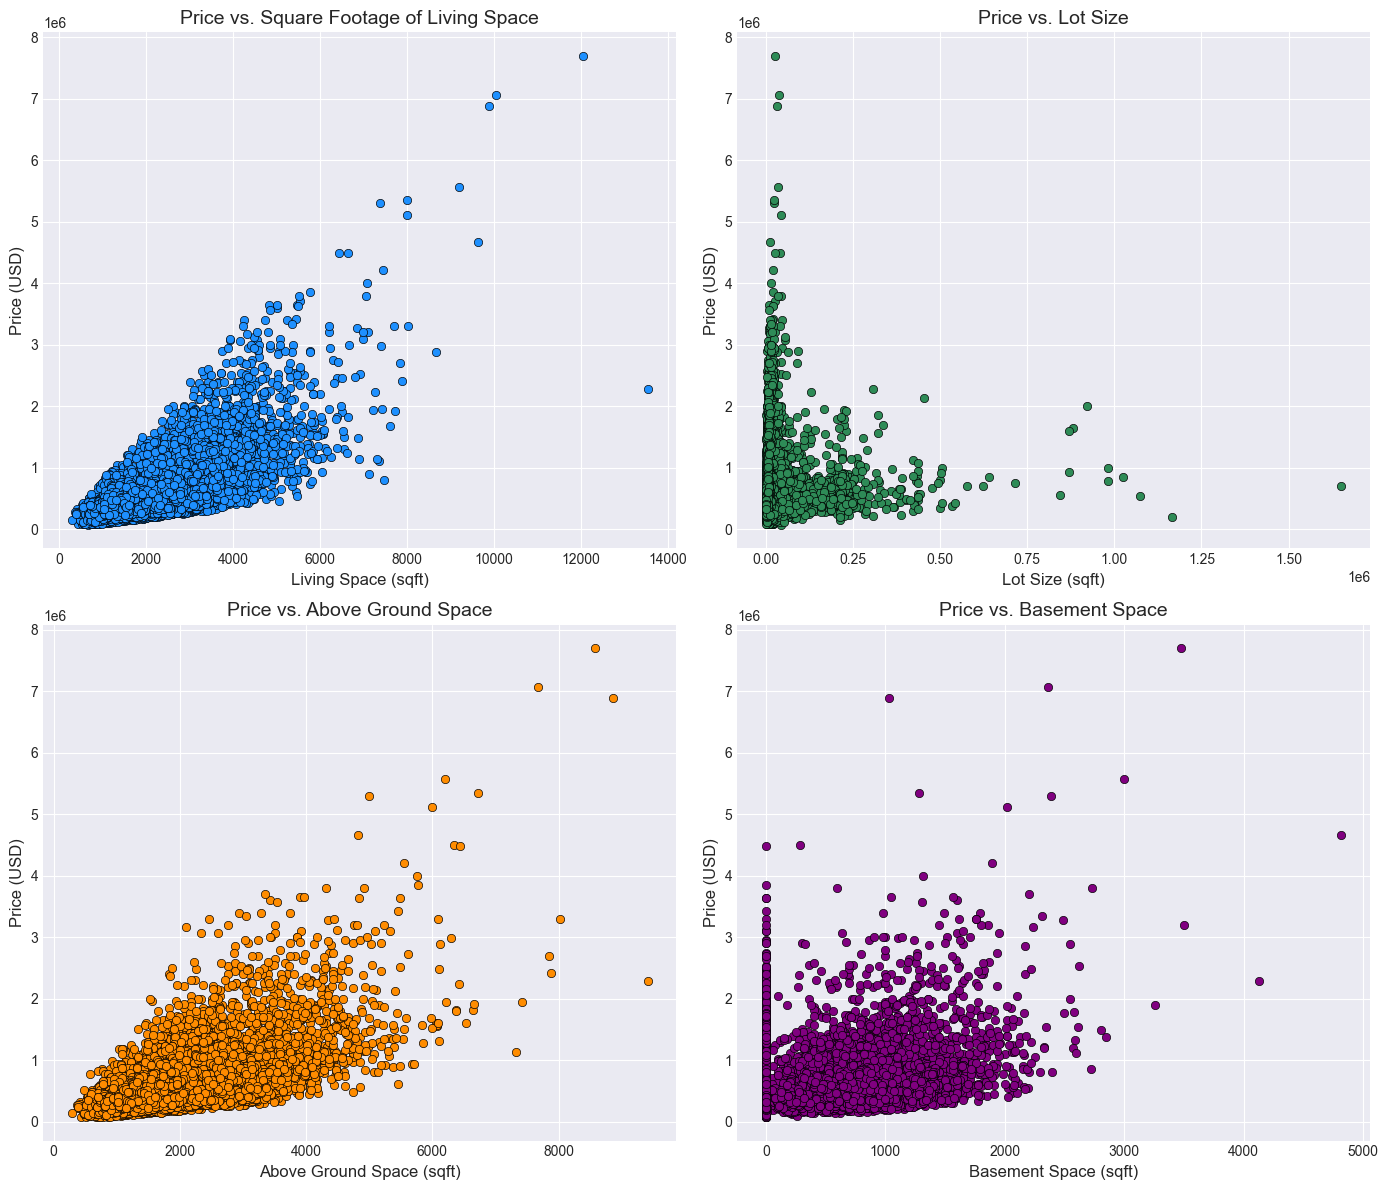

In [10]:
plt.style.use('seaborn-darkgrid')
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

sns.scatterplot(x='sqft_living', y='price', data=df, ax=axes[0, 0], color='dodgerblue', edgecolor='black')
axes[0, 0].set_title('Price vs. Square Footage of Living Space', fontsize=14)
axes[0, 0].set_xlabel('Living Space (sqft)', fontsize=12)
axes[0, 0].set_ylabel('Price (USD)', fontsize=12)

sns.scatterplot(x='sqft_lot', y='price', data=df, ax=axes[0, 1], color='seagreen', edgecolor='black')
axes[0, 1].set_title('Price vs. Lot Size', fontsize=14)
axes[0, 1].set_xlabel('Lot Size (sqft)', fontsize=12)
axes[0, 1].set_ylabel('Price (USD)', fontsize=12)

sns.scatterplot(x='sqft_above', y='price', data=df, ax=axes[1, 0], color='darkorange', edgecolor='black')
axes[1, 0].set_title('Price vs. Above Ground Space', fontsize=14)
axes[1, 0].set_xlabel('Above Ground Space (sqft)', fontsize=12)
axes[1, 0].set_ylabel('Price (USD)', fontsize=12)

sns.scatterplot(x='sqft_basement', y='price', data=df, ax=axes[1, 1], color='purple', edgecolor='black')
axes[1, 1].set_title('Price vs. Basement Space', fontsize=14)
axes[1, 1].set_xlabel('Basement Space (sqft)', fontsize=12)
axes[1, 1].set_ylabel('Price (USD)', fontsize=12)

plt.tight_layout()
plt.show()


The plots reveal a strong positive correlation between `sqft_living`, `sqft_above`, and the number of rooms. Additionally, the presence or absence of a basement also shows a relationship with the price. To simplify, we select `sqft_living` and the `dummy_basement` as key area-related features.

<Axes: xlabel='sqft_basement', ylabel='Density'>

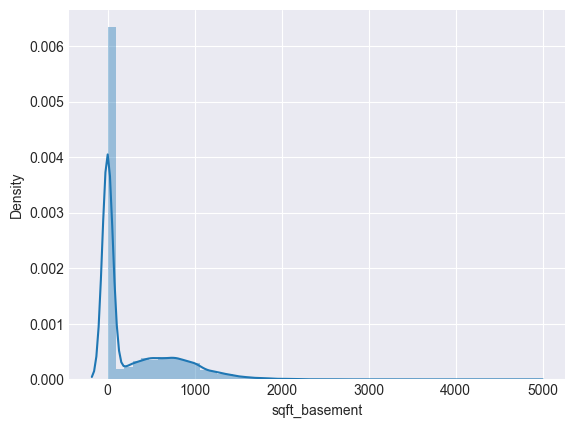

In [11]:
# basement distribution
sns.distplot(df.sqft_basement)

In [12]:
df['dummy_basement'] = (df.sqft_basement != 0).astype(int)
df['dummy_basement'].value_counts()

dummy_basement
0    13126
1     8487
Name: count, dtype: int64

### Location
The geographical location of a property influences its room configuration, as prime locations often feature larger homes with more rooms to meet higher market demand and accommodate families.

In [13]:
# Zip codes are critical for determining the geographical location of a property, which directly influences its price.
search_engine = SearchEngine()
city_list = []

# Loop through each zip code and retrieve the corresponding city name
for zip_code in df.zipcode:
    city_name = search_engine.by_zipcode(str(zip_code)).major_city
    city_list.append(city_name)

# The city names are added to the DataFrame based on the zip codes
df['city'] = city_list

### Floors, Waterfront, View, Condition
We will analyze how factors like floors, waterfront, view, and condition impact house prices to identify key price determinants.

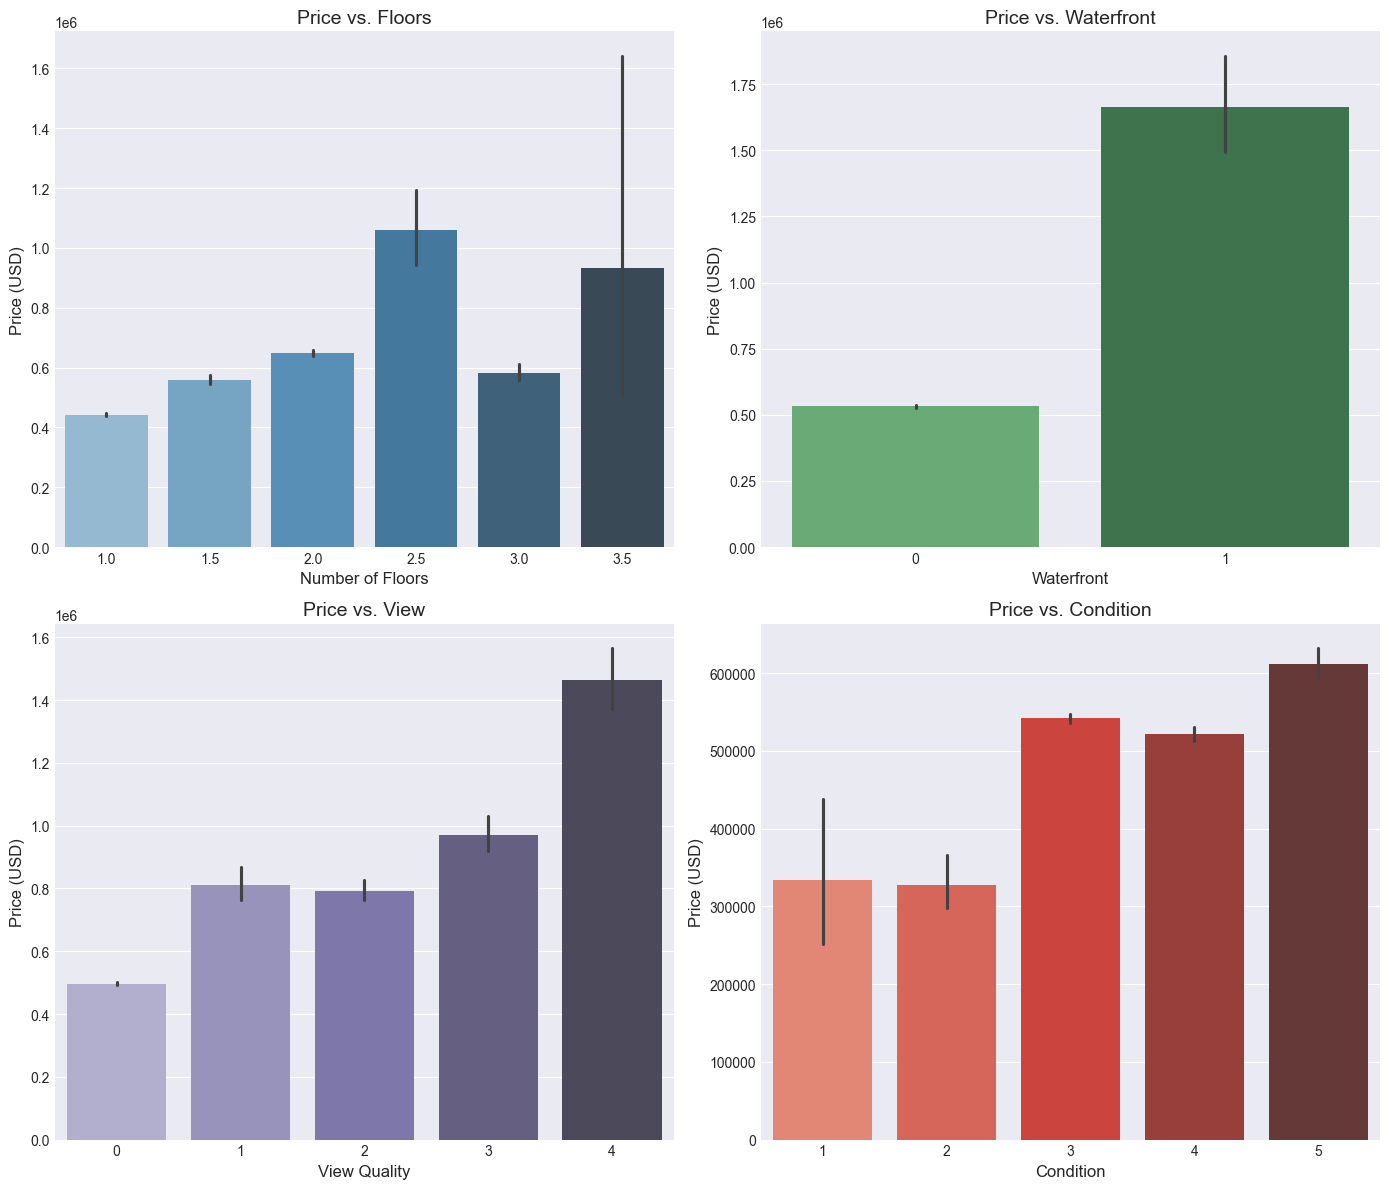

In [14]:
plt.style.use('seaborn-darkgrid')
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# Plot Price vs Floors
sns.barplot(x='floors', y='price', data=df, ax=axes[0, 0], palette='Blues_d')
axes[0, 0].set_title('Price vs. Floors', fontsize=14)
axes[0, 0].set_xlabel('Number of Floors', fontsize=12)
axes[0, 0].set_ylabel('Price (USD)', fontsize=12)

# Plot Price vs Waterfront
sns.barplot(x='waterfront', y='price', data=df, ax=axes[0, 1], palette='Greens_d')
axes[0, 1].set_title('Price vs. Waterfront', fontsize=14)
axes[0, 1].set_xlabel('Waterfront', fontsize=12)
axes[0, 1].set_ylabel('Price (USD)', fontsize=12)

# Plot Price vs View
sns.barplot(x='view', y='price', data=df, ax=axes[1, 0], palette='Purples_d')
axes[1, 0].set_title('Price vs. View', fontsize=14)
axes[1, 0].set_xlabel('View Quality', fontsize=12)
axes[1, 0].set_ylabel('Price (USD)', fontsize=12)

# Plot Price vs Condition
sns.barplot(x='condition', y='price', data=df, ax=axes[1, 1], palette='Reds_d')
axes[1, 1].set_title('Price vs. Condition', fontsize=14)
axes[1, 1].set_xlabel('Condition', fontsize=12)
axes[1, 1].set_ylabel('Price (USD)', fontsize=12)

plt.tight_layout()
plt.show()

### Key Features Identified for Price Prediction

Based on the preliminary analysis, we have identified several key features that are likely to influence house prices. These features include:

- Building age (`building_age`)
- House grade (`grade`)
- Number of bedrooms (`bedrooms`)
- Number of bathrooms (`bathrooms`)
- Living area (`sqft_living`)
- Presence of a basement (`dummy_basement`)
- Location (`city`)
- Waterfront status (`waterfront`)
- View quality (`view`)
- Overall condition (`condition`)

In the subsequent data distribution analysis and multiple regression analysis, we will focus on these features to construct a regression model to predict house prices, examining how these factors collectively impact the pricing.


In [15]:
key_features=['price', 'building_age', 'grade', 'bedrooms', 'bathrooms', 'sqft_living', 'dummy_basement', 'waterfront', 'view', 'condition', 'city']
len(key_features)

11

## Distribution of features
This section visualizes the distribution of key features selected for predicting housing prices, including bedrooms, sqft_living, condition, and city. By examining these distributions, we can assess the characteristics of each feature, such as skewness or outliers, which may influence the model’s accuracy.

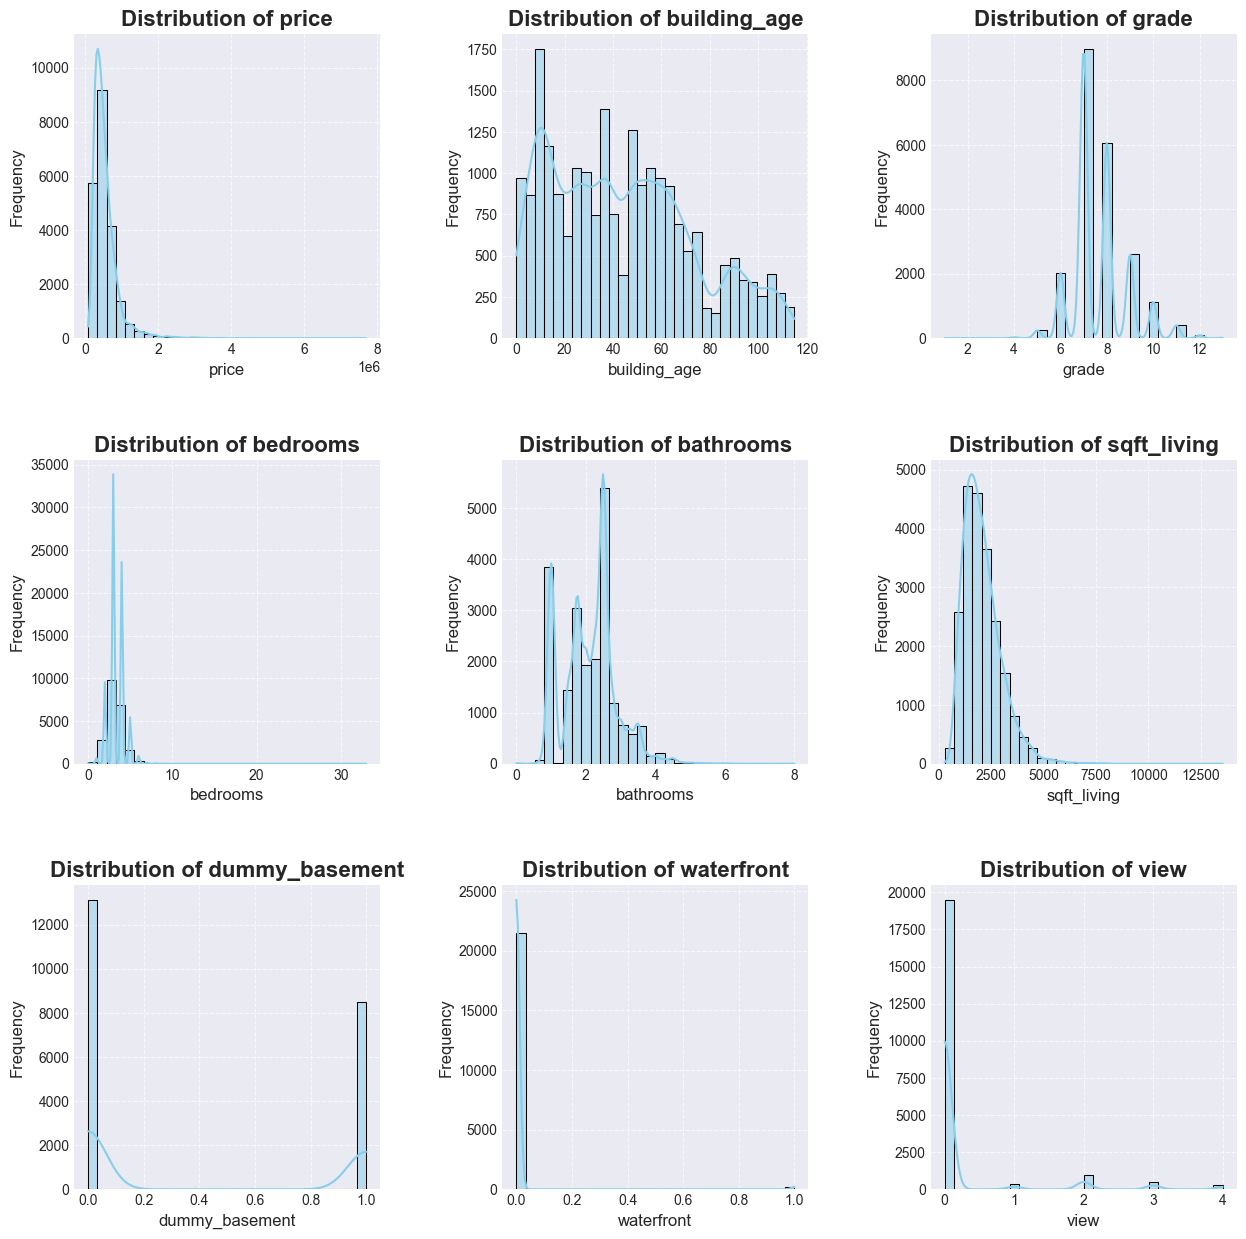

In [16]:
plt.figure(figsize=(15, 15))

for idx, feature in enumerate(key_features[:9]):
    plt.subplot(3, 3, idx + 1)
    sns.histplot(df[feature], kde=True, color='skyblue', bins=30, edgecolor='black')
    plt.title(f"Distribution of {feature}", fontsize=16, weight='bold')
    plt.xlabel(feature, fontsize=12)
    plt.ylabel('Frequency', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.7)

plt.subplots_adjust(hspace=0.4, wspace=0.4)
plt.show()


Due to the presence of some outliers, the distribution of house prices deviates from the expected pattern with respect to various features.

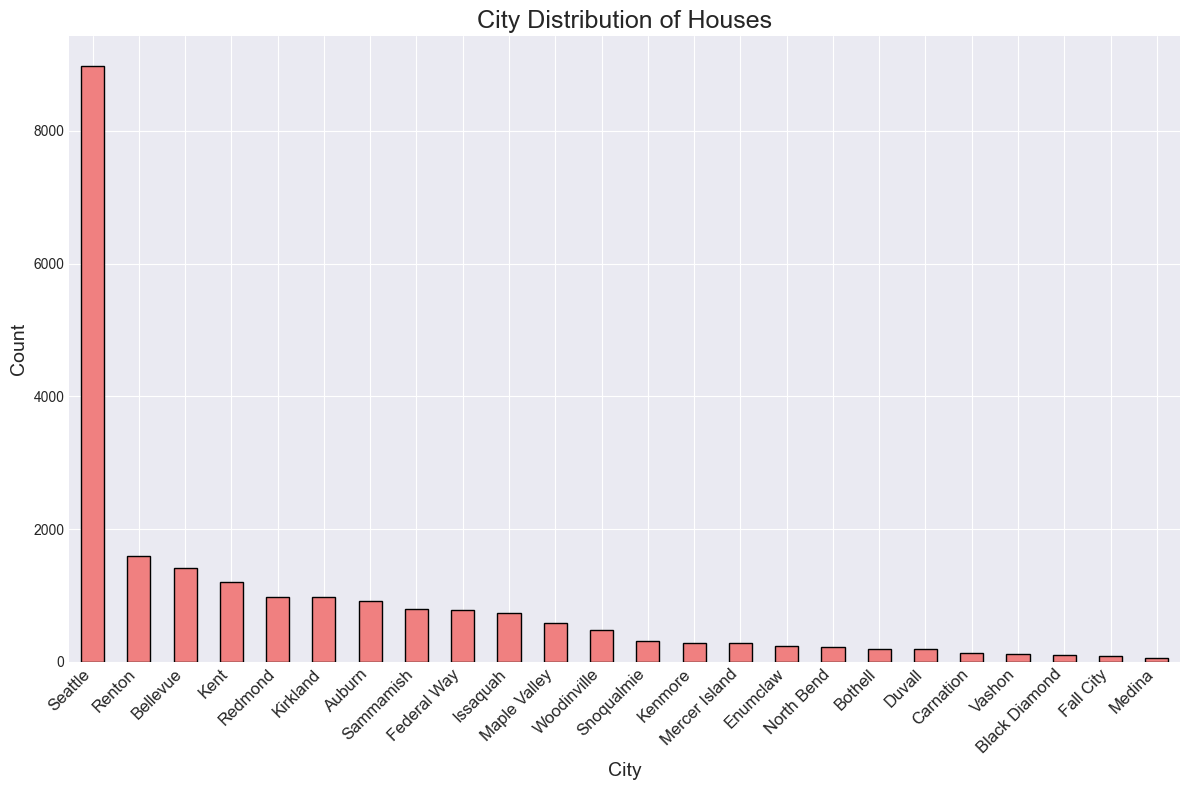

In [17]:
# Plot the distribution of the 'city' column
city_counts = df['city'].value_counts()

plt.figure(figsize=(12, 8))
city_counts.plot(kind='bar', color='lightcoral', edgecolor='black')

plt.title('City Distribution of Houses', fontsize=18)
plt.xlabel('City', fontsize=14)
plt.ylabel('Count', fontsize=14)

plt.xticks(rotation=45, ha='right', fontsize=12)

plt.tight_layout()
plt.show()

## Outliers removal
Outliers are extreme values that deviate significantly from the majority of the data, which can skew statistical analysis and negatively impact model performance. In our analysis, we focused on identifying and removing outliers to ensure the integrity of the data. By eliminating these extreme values, we aim to build a more reliable and accurate model. The function we used visualizes the data distribution both before and after outlier removal, helping us ensure that the model is trained on representative data, which is crucial for enhancing its generalization and predictive performance.

In [18]:
def remove_outliers(df, col, lower_quantile=0.05, upper_quantile=0.95):
    """
    Remove outliers based on specified quantiles and visualize the distributions before and after removal.

    Parameters:
    df (DataFrame): The input DataFrame.
    col (str): The column name for which outliers need to be removed.
    lower_quantile (float): The lower quantile threshold for filtering out outliers (default is 0.05).
    upper_quantile (float): The upper quantile threshold for filtering out outliers (default is 0.95).

    Returns:
    DataFrame: The DataFrame after removing outliers.
    """
    
    plt.style.use('seaborn-darkgrid')

    lower_threshold = df[col].quantile(lower_quantile)
    upper_threshold = df[col].quantile(upper_quantile)
    df_filtered = df[(df[col] >= lower_threshold) & (df[col] <= upper_threshold)]

    plt.figure(figsize=(15, 6))

    plt.subplot(1, 2, 1)
    sns.histplot(df[col], kde=True, color='skyblue', bins=30, edgecolor='black')
    plt.title(f'Distribution of {col} Before Outlier Removal', fontsize=16, weight='bold')
    plt.xlabel(col, fontsize=14)
    plt.ylabel('Frequency', fontsize=14)
    plt.grid(True, linestyle='--', alpha=0.7)

    plt.subplot(1, 2, 2)
    sns.histplot(df_filtered[col], kde=True, color='seagreen', bins=30, edgecolor='black')
    plt.title(f'Distribution of {col} After Outlier Removal', fontsize=16, weight='bold')
    plt.xlabel(col, fontsize=14)
    plt.ylabel('Frequency', fontsize=14)
    plt.grid(True, linestyle='--', alpha=0.7)

    plt.tight_layout()
    plt.show()
    
    return df_filtered


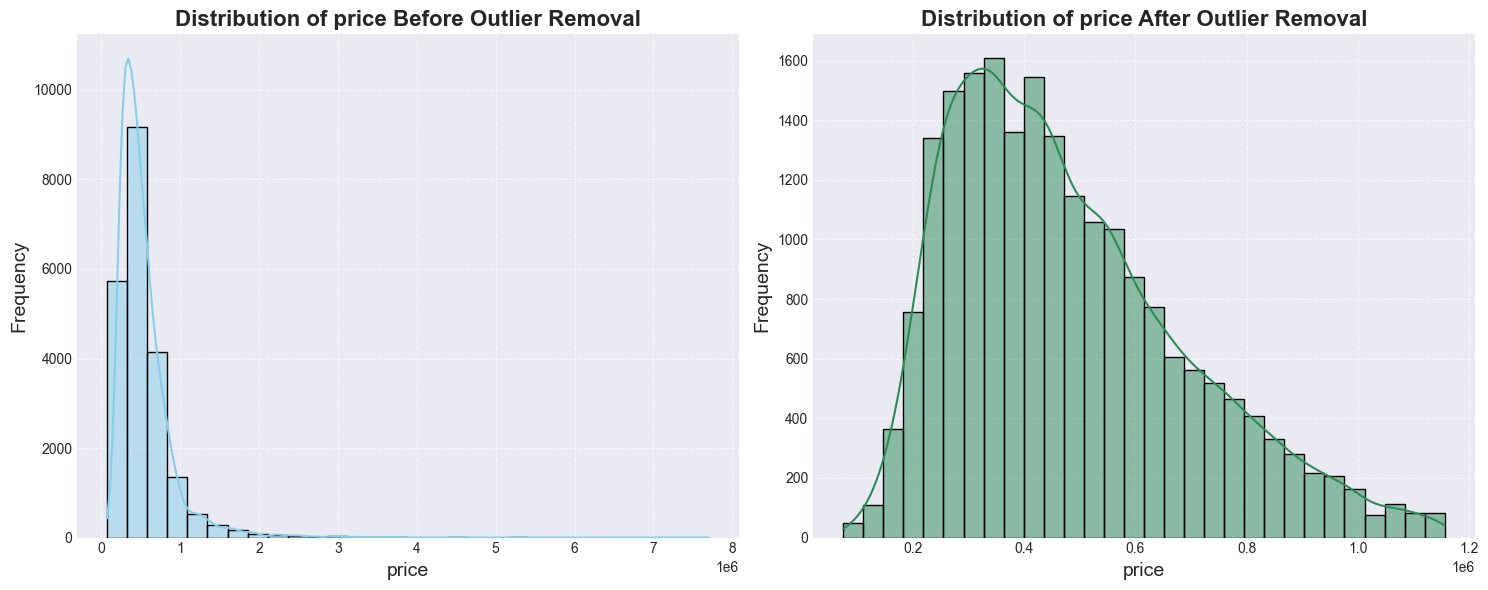

In [19]:
# price 
df_1=remove_outliers(df, 'price',0.00, 0.95)

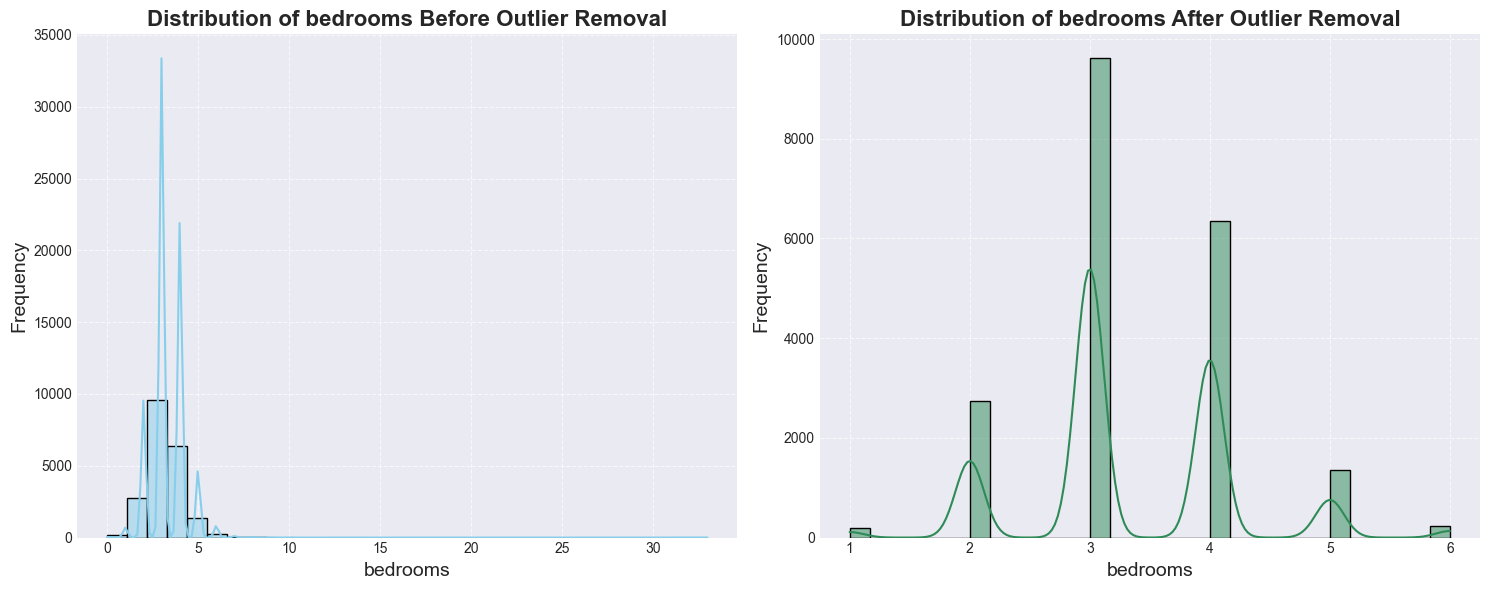

In [20]:
# bedrooms
df_2=remove_outliers(df_1, 'bedrooms', 0.01, 0.99)

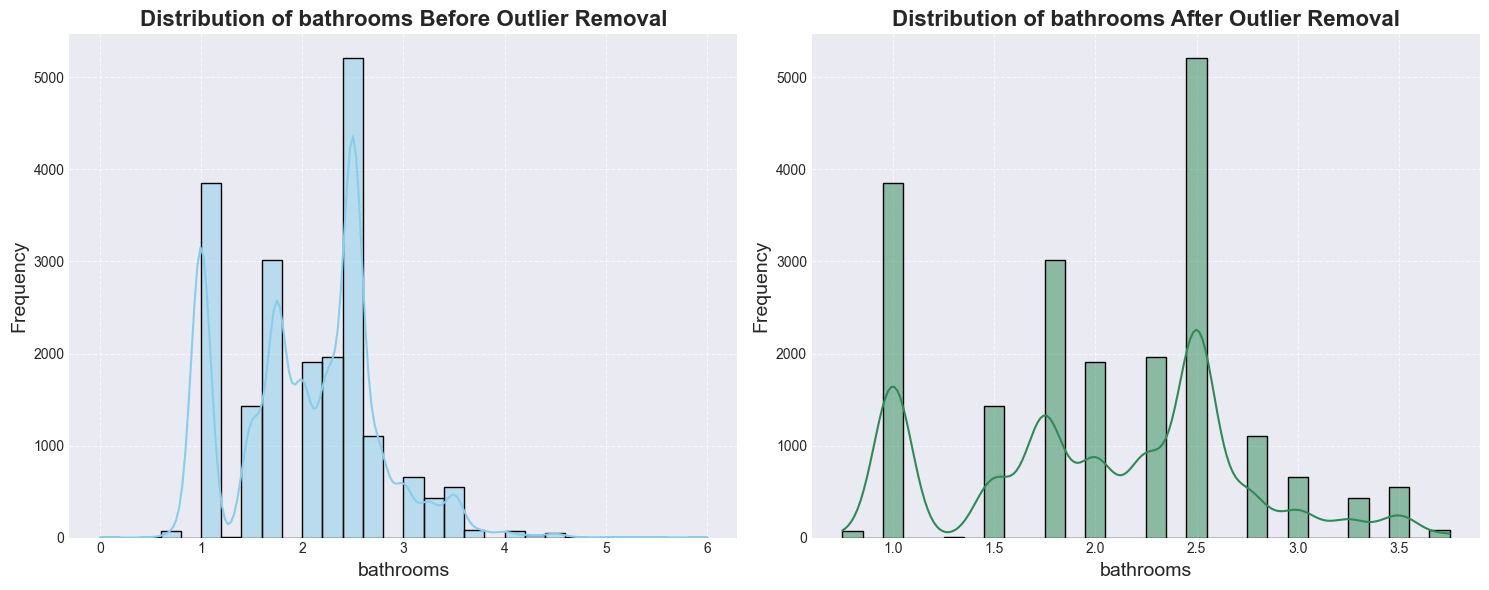

In [21]:
# bathrooms
df_3=remove_outliers(df_2, 'bathrooms', 0.001, 0.99)

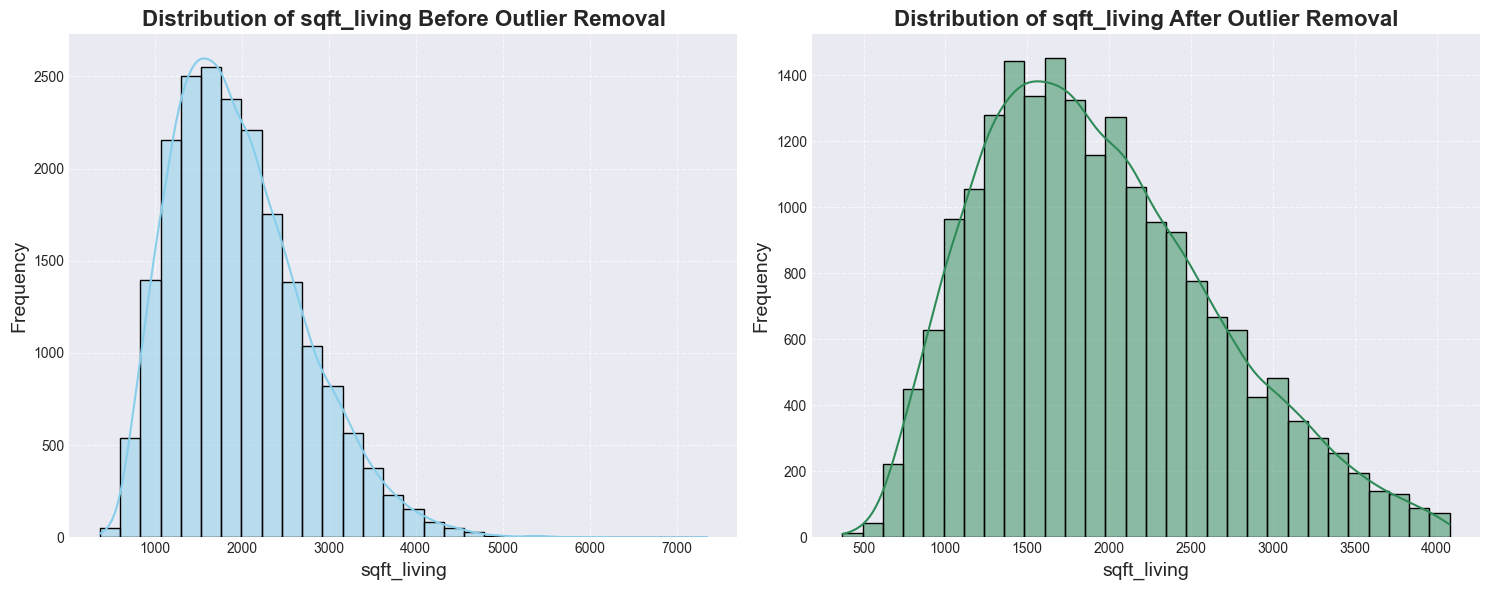

In [22]:
# sqft_living
df_4=remove_outliers(df_3, 'sqft_living', 0.00, 0.99)

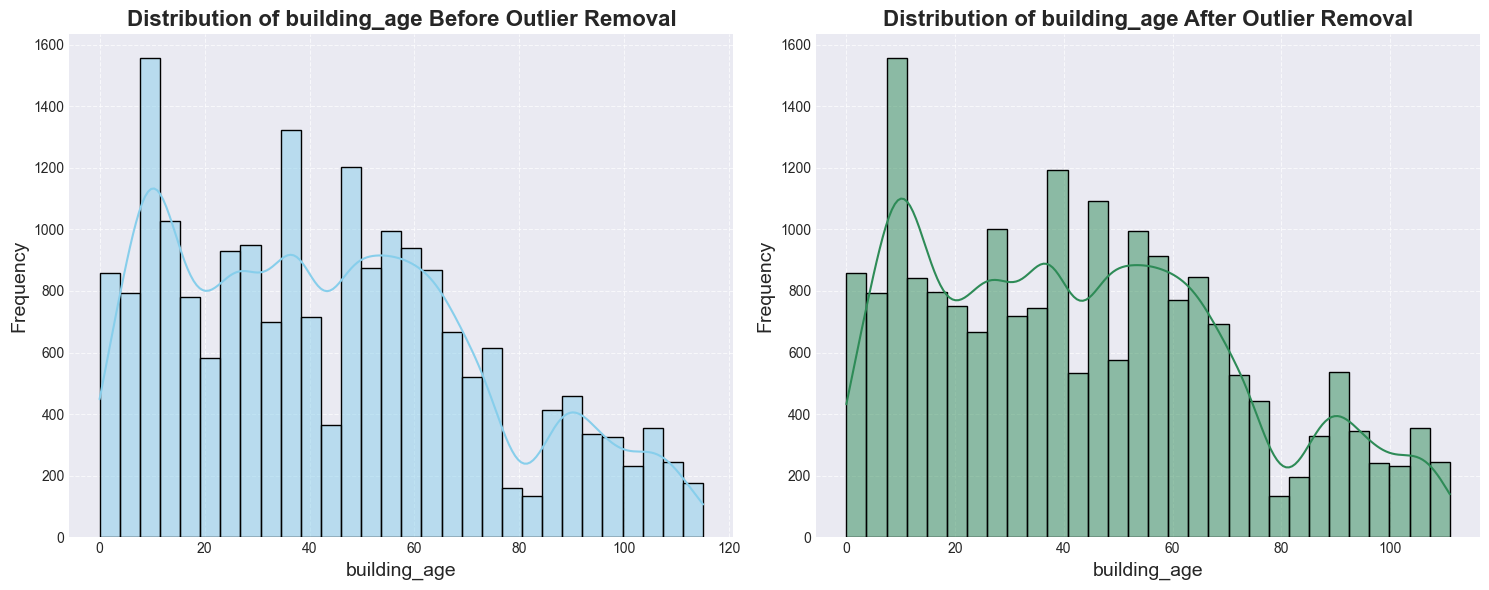

In [23]:
# building_age
df_or=remove_outliers(df_4, 'building_age', 0.00, 0.99)

In our analysis, we applied logarithmic transformations to variables such as `price` and `sqft_living`, as these features exhibited relatively large values. This transformation helps mitigate the potential for excessively large coefficients in the multivariate linear regression model. After removing outliers, we compared the distribution of the transformed data. The results demonstrate that, for most features, the distribution of `price` aligns with our expectations, indicating a more normalized relationship between `price` and the other variables.

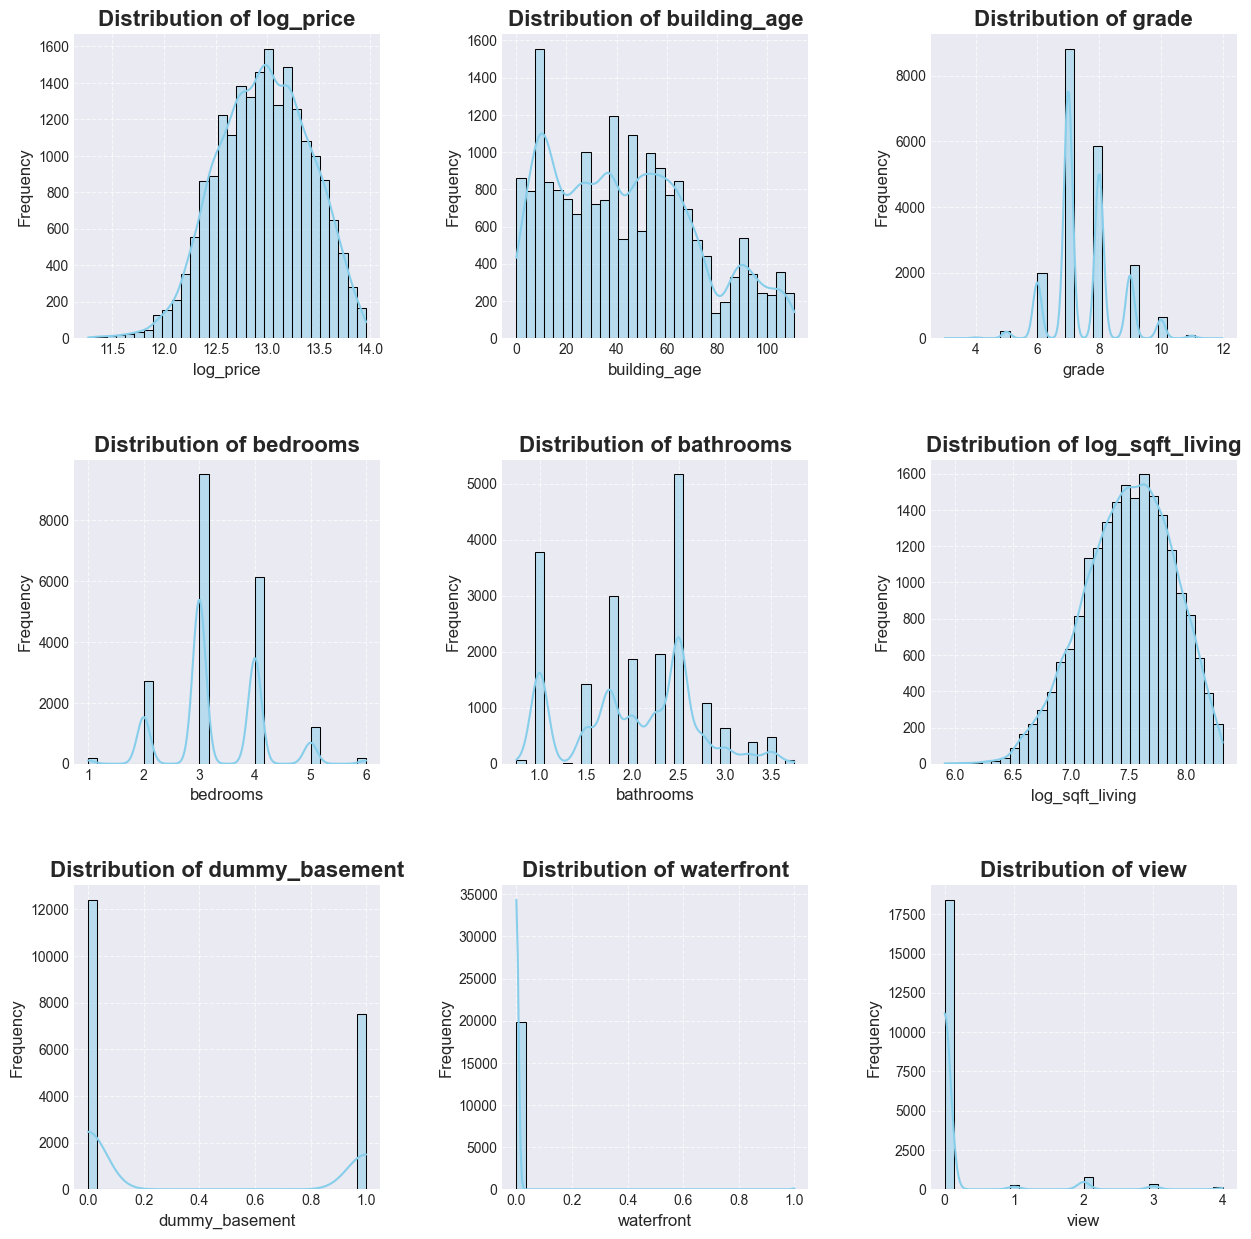

In [24]:
# Create new columns for log-transformed features
df_or['log_sqft_living'] = np.log(df_or['sqft_living'])
df_or['log_price'] = np.log(df_or['price'])
feature_list = ['log_price', 'building_age', 'grade', 'bedrooms', 'bathrooms', 'log_sqft_living', 'dummy_basement', 'waterfront', 'view', 'condition', 'city']

plt.figure(figsize=(15, 15))
for idx, feature in enumerate(feature_list[:9]):
    plt.subplot(3, 3, idx + 1)
    sns.histplot(df_or[feature], kde=True, color='skyblue', bins=30, edgecolor='black')
    plt.title(f"Distribution of {feature}", fontsize=16, weight='bold')
    plt.xlabel(feature, fontsize=12)
    plt.ylabel('Frequency', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.7)

plt.subplots_adjust(hspace=0.4, wspace=0.4)
plt.show()


## Assessing Linearity and Variance Consistency

In this section, we evaluate the linear relationships between features and the consistency of variance using scatter plots. By comparing the feature relationships before and after transformation, we assess whether the transformations enhance linearity and ensure more stable variance, thereby improving the overall performance of the model.

### Price with Bedrooms

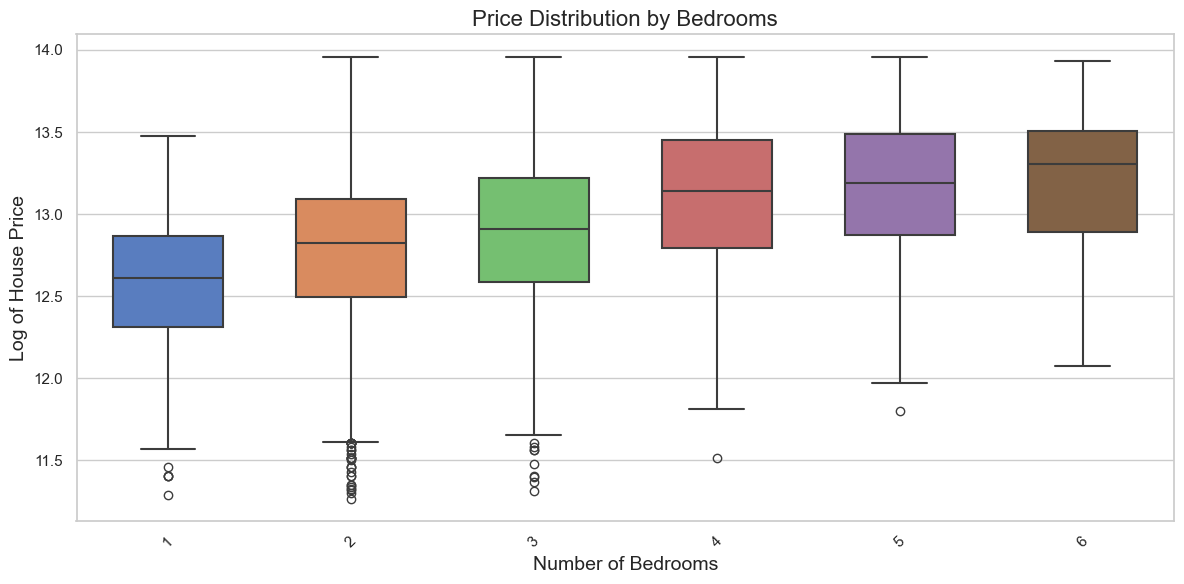

In [25]:
sns.set_theme(style="whitegrid")

plt.figure(figsize=(12, 6))

sns.boxplot(x=df_or['bedrooms'], y=np.log(df_or['price']), palette="muted", width=0.6, fliersize=6, linewidth=1.5)

plt.title('Price Distribution by Bedrooms', fontsize=16)
plt.xlabel('Number of Bedrooms', fontsize=14)
plt.ylabel('Log of House Price', fontsize=14)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

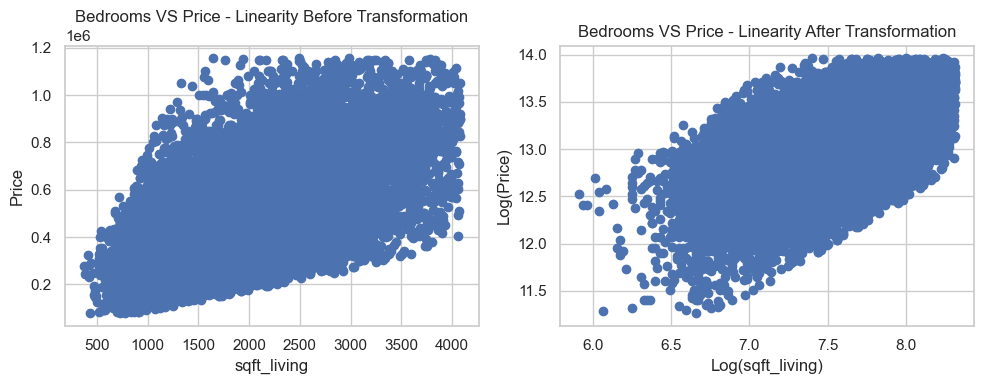

In [26]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.scatter(df_or['sqft_living'], df_or['price'])
plt.title('Bedrooms VS Price - Linearity Before Transformation')
plt.xlabel('sqft_living')
plt.ylabel('Price')

plt.subplot(1, 2, 2)
plt.scatter(np.log(df_or['sqft_living']), np.log(df_or['price']))
plt.title('Bedrooms VS Price - Linearity After Transformation')
plt.xlabel('Log(sqft_living)')
plt.ylabel('Log(Price)')

plt.tight_layout()
plt.show()

### Price with Basement


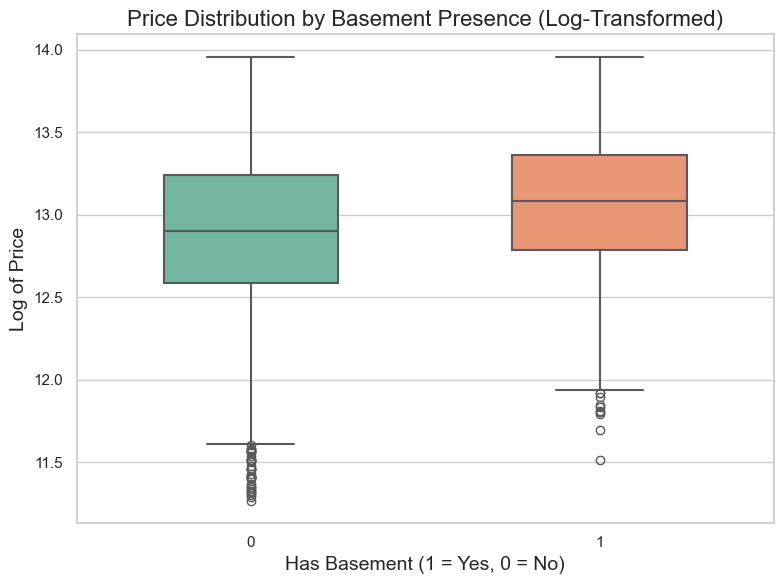

In [27]:
sns.set_theme(style="whitegrid")

plt.figure(figsize=(8, 6))
sns.boxplot(x=df_or['dummy_basement'], y=np.log(df_or['price']), palette="Set2", width=0.5, fliersize=6, linewidth=1.5)

plt.title('Price Distribution by Basement Presence (Log-Transformed)', fontsize=16)
plt.xlabel('Has Basement (1 = Yes, 0 = No)', fontsize=14)
plt.ylabel('Log of Price', fontsize=14)

plt.tight_layout()
plt.show()

### Price with Grade


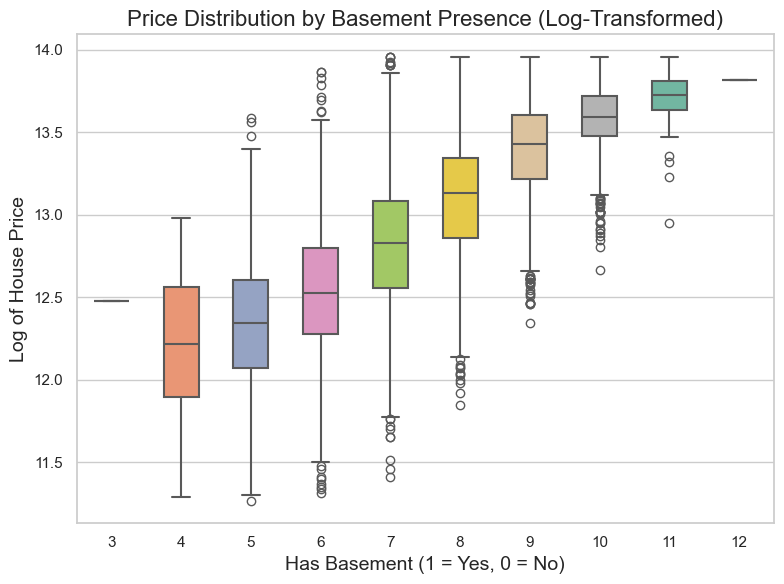

In [28]:
sns.set_theme(style="whitegrid")

plt.figure(figsize=(8, 6))

sns.boxplot(x=df_or['grade'], y=np.log(df_or['price']), palette="Set2", width=0.5, fliersize=6, linewidth=1.5)

plt.title('Price Distribution by Basement Presence (Log-Transformed)', fontsize=16)
plt.xlabel('Has Basement (1 = Yes, 0 = No)', fontsize=14)
plt.ylabel('Log of House Price', fontsize=14)

plt.tight_layout()
plt.show()

### Price with Location 

In [29]:
# Select relevant columns (price, city, lat, long) from the original dataframe and group by 'city'
geo_df = df_or[['price', 'city', 'lat', 'long']].groupby('city')[['price', 'lat', 'long']].mean().reset_index()

# Display the first few rows of the new dataframe
geo_df.head()

,city,price,lat,long
0,Auburn,286259.534155,47.306286,-122.219197
1,Bellevue,675510.421005,47.592665,-122.150150
2,Black Diamond,421316.842105,47.333740,-121.998989
3,Bothell,482861.968586,47.755479,-122.200990
4,Carnation,421084.218487,47.672473,-121.845723


In [30]:
# read the shape data 
shp = gpd.read_file('kc-shp')

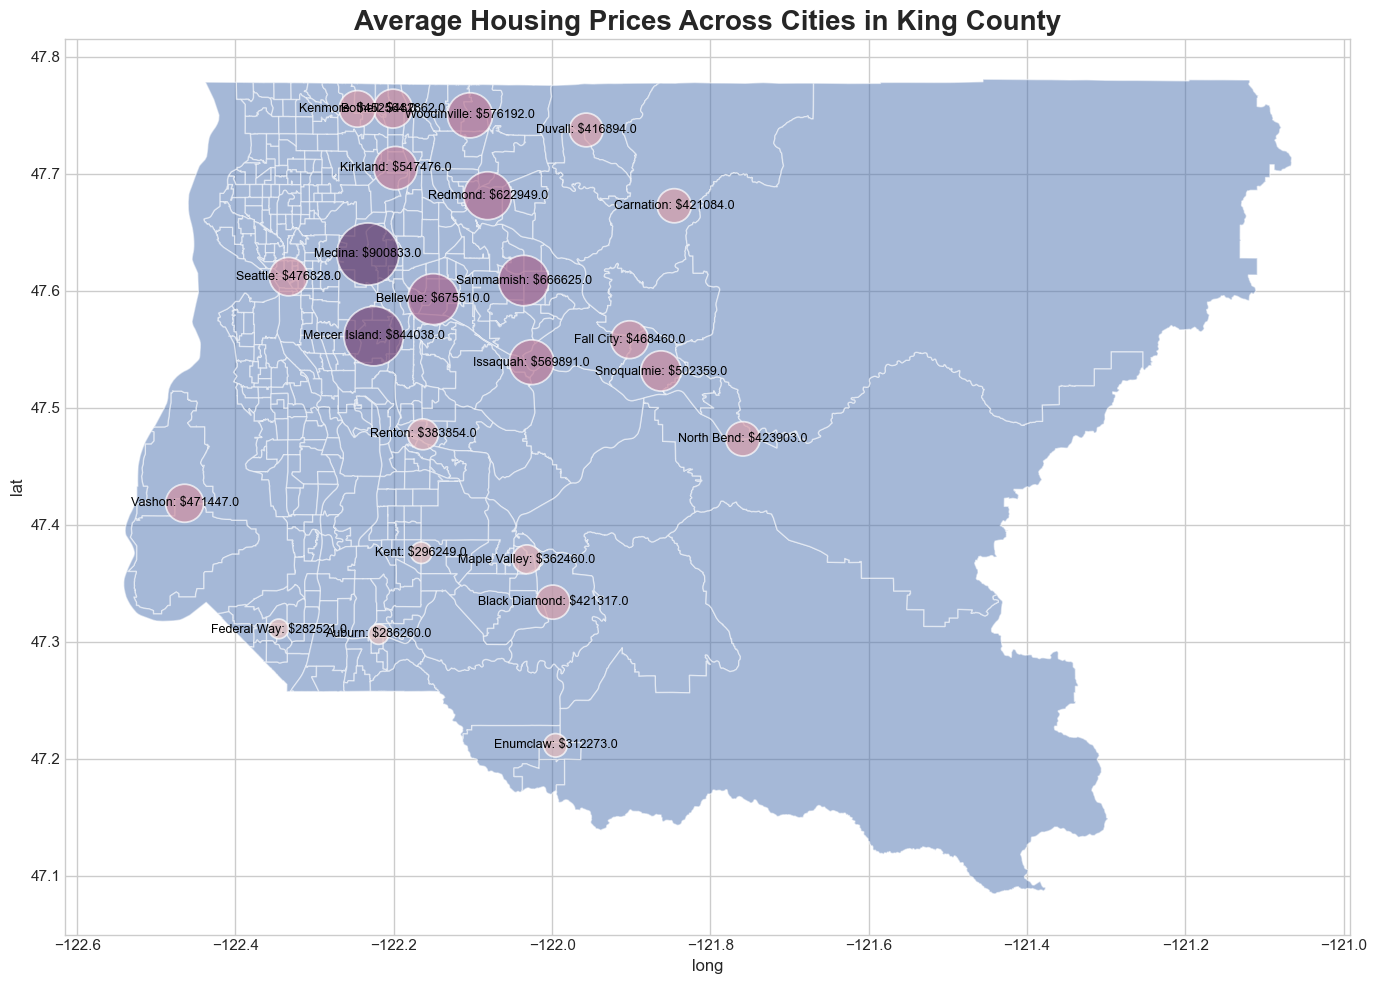

In [31]:
plt.style.use('seaborn-whitegrid')
fig, ax = plt.subplots(figsize=(15, 10))
cmap = sns.cubehelix_palette(dark=.3, light=.8, as_cmap=True)
shp.plot(ax=ax, alpha=0.5)

scatter = sns.scatterplot(x=geo_df['long'], y=geo_df['lat'], alpha=0.7,
                          size=geo_df['price'], hue=geo_df['price'],
                          sizes=(200, 2000), palette=cmap, legend=None)

for i in range(len(geo_df)):
    ax.text(geo_df['long'][i], geo_df['lat'][i], 
            '{}: ${}'.format(geo_df['city'][i], round(geo_df['price'][i], 0)),
            fontsize=9, ha='center', va='center', color='black')

plt.title('Average Housing Prices Across Cities in King County', fontsize=20, weight='bold')
plt.tight_layout()
plt.show()

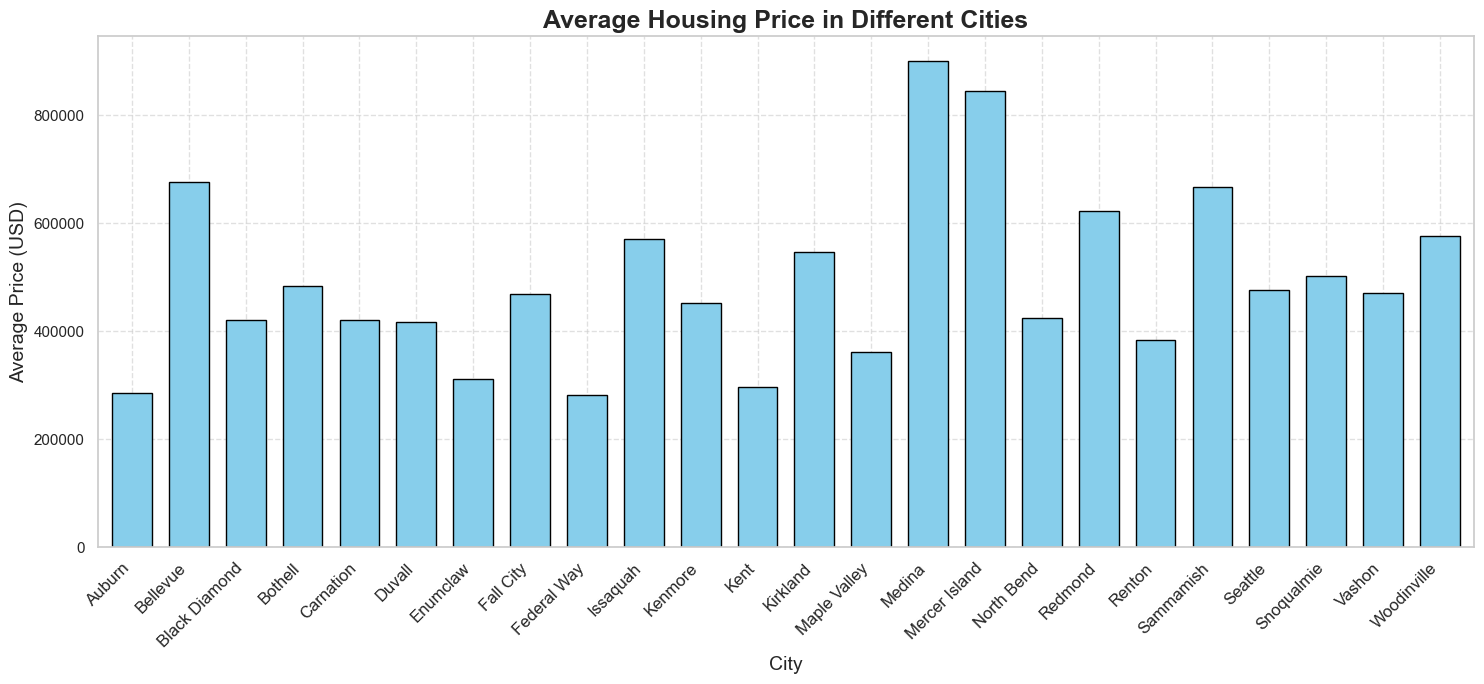

In [32]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(15, 7))  # Adjust figure size for better readability
ax = geo_df.groupby('city')['price'].mean().plot(kind='bar', 
                                                 color='skyblue', 
                                                 edgecolor='black', 
                                                 width=0.7)  # Customize the color and width

ax.set_title('Average Housing Price in Different Cities', fontsize=18, fontweight='bold')
ax.set_xlabel('City', fontsize=14)
ax.set_ylabel('Average Price (USD)', fontsize=14)
plt.xticks(rotation=45, ha='right', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

### Why We Create Dummy Variables for the 'City' Column

In many machine learning algorithms and statistical models, categorical variables such as "city" need to be converted into numerical form. This is because most algorithms require numerical input, and categorical variables cannot be directly used in models. To achieve this, we use a technique called **dummy encoding**.

Dummy variables are binary (0 or 1) columns that represent the presence or absence of a category. By creating these dummy variables, we can transform the "city" column, which contains categorical data (the names of different cities), into a numerical format that models can interpret.


In [33]:
dummies = pd.get_dummies(df_or['city'], drop_first=True)

### Feature Selection

In [34]:
features = ['log_price', 'bedrooms', 'bathrooms', 'log_sqft_living', 'dummy_basement', 
            'condition', 'view', 'waterfront', 'grade', 'building_age']

new_df = df_or[features].join(dummies)
new_df.head()

,log_price,bedrooms,bathrooms,log_sqft_living,dummy_basement,condition,view,waterfront,grade,building_age,...,Medina,Mercer Island,North Bend,Redmond,Renton,Sammamish,Seattle,Snoqualmie,Vashon,Woodinville
0,12.309982,3,1.00,7.073270,0,3,0,0,7,60,...,False,False,False,False,False,False,True,False,False,False
1,13.195614,3,2.25,7.851661,1,3,0,0,7,64,...,False,False,False,False,False,False,True,False,False,False
2,12.100712,2,1.00,6.646391,0,3,0,0,6,82,...,False,False,False,False,False,False,False,False,False,False
3,13.311329,4,3.00,7.580700,1,5,0,0,7,50,...,False,False,False,False,False,False,True,False,False,False
4,13.142166,3,2.00,7.426549,0,3,0,0,8,28,...,False,False,False,False,False,True,False,False,False,False


### Heatmap without City

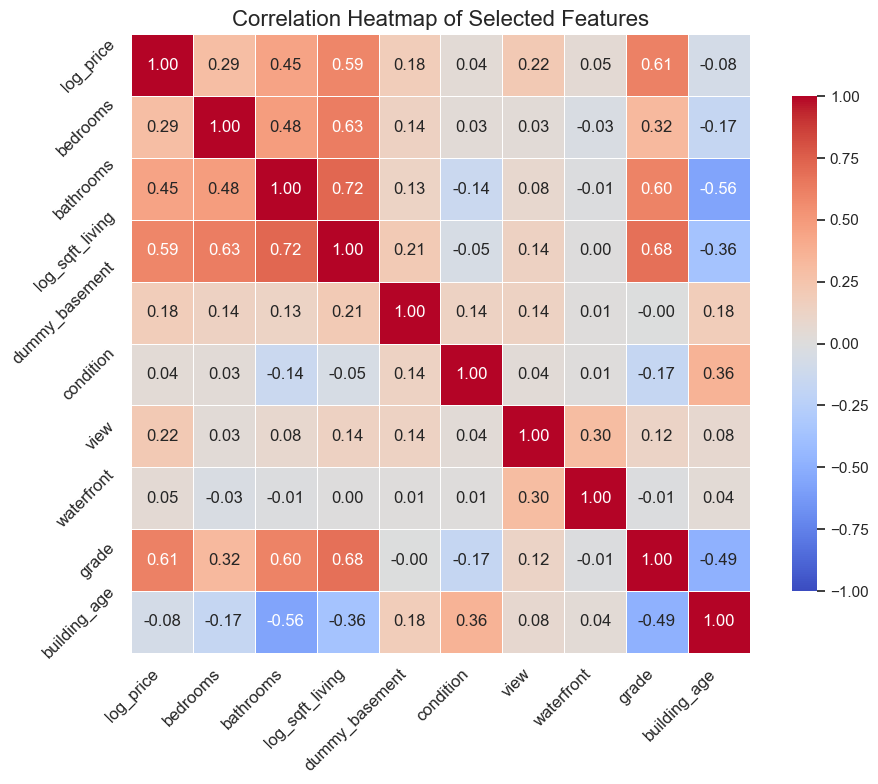

In [35]:
df_corr = df_or[features]

corr_matrix = df_corr.corr()

plt.figure(figsize=(10, 8))

sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5, cbar_kws={'shrink': 0.8},
            annot_kws={"size": 12}, square=True, vmin=-1, vmax=1)

plt.title('Correlation Heatmap of Selected Features', fontsize=16)
plt.xticks(rotation=45, ha='right', fontsize=12)
plt.yticks(rotation=45, ha='right', fontsize=12)

plt.tight_layout()
plt.show()

At this point, we have thoroughly analyzed and selected the key variables that are closely related to house prices, while also addressing the outliers to ensure data quality. Through this process, we have compiled a comprehensive list of relevant features, which now serves as the foundation for our forthcoming multiple regression analysis. With these features, we are well-equipped to construct and evaluate our regression model, ensuring that it accurately captures the relationships between the variables and the target variable, price.

### Split the Train Set and Test Set

In [36]:
# declare independent and dependent variables
inputs=new_df.drop(columns='log_price')
target=new_df.log_price

# Split the variables with an 80-20 split and some random state
x_train, x_test, y_train, y_test = train_test_split(inputs, target, test_size=0.3, random_state=100)

print("Training set - Features: ", x_train.shape, "Target: ", y_train.shape)
print("Test set- Features: ", x_test.shape, "Target: ",y_test.shape)

Training set - Features:  (13946, 32) Target:  (13946,)
Test set- Features:  (5977, 32) Target:  (5977,)


In [37]:
x_train =pd.DataFrame(data=x_train, columns=inputs.columns)
x_test =pd.DataFrame(data=x_test, columns=inputs.columns)

## Linear Regresson
In this section, Linear Regression was applied to predict housing prices in King County. The coefficients show that most features positively influence housing prices, with only a few having a negative effect. The p-values indicate that all features are statistically significant (p < 0.05). The residual analysis of both the training and testing datasets shows minimal deviation. Moreover, the scatter plots of actual vs predicted values reveal a close alignment along a 45-degree line, suggesting that the model's predictions are highly accurate and the model performs well.

### LinearRegression

In [38]:
# fit the model 
linear_regression = LinearRegression()
linear_regression.fit(x_train,y_train)

LinearRegression()

### $R^2$

$R^2$ , or **coefficient of determination**, measures how well a regression model explains the variance in the target variable.
$$
R^2 = 1 - \frac{SS_{\text{res}}}{SS_{\text{tot}}}
$$
Where:
- $ SS_{\text{res}} $ is the residual sum of squares (differences between actual and predicted values).
- $ SS_{\text{tot}} $ is the total sum of squares (differences between actual values and their mean).

$ R^2 $ measures the proportion of variance in the target variable explained by the model, with values ranging from 0 (no fit) to 1 (perfect fit).

In [39]:
linear_regression.score(x_train,y_train)

0.7093705076087473

### Coefficient and Intercept

In [40]:

linear_regression.coef_


array([-0.03620103,  0.0817188 ,  0.40485443, -0.01170191,  0.04835123,
        0.04670242,  0.23285684,  0.16160169,  0.00287119,  0.656282  ,
        0.31097657,  0.41699396,  0.34700788,  0.35572903,  0.06784497,
        0.4450162 , -0.04225416,  0.51811814,  0.38900451,  0.04135308,
        0.59098595,  0.18384099,  1.28309604,  0.79445121,  0.35828593,
        0.60056379,  0.23177587,  0.53499361,  0.47577392,  0.43430947,
        0.36608761,  0.47055561])

In [41]:
linear_regression.intercept_

7.981368727826353

In a multiple linear regression model, the relationship between house price $ \text{price} $ and the features $ X_1, X_2, \dots, X_n $ can be represented by the following expression:

$$
\text{price} = \beta_0 + \beta_1 X_1 + \beta_2 X_2 + \dots + \beta_n X_n
$$

Where:

- $ \beta_0 $ is the intercept (i.e., \texttt{linear\_regression.intercept\_}).
- $ \beta_1, \beta_2, \dots, \beta_n $ are the regression coefficients for each feature (i.e., the values in \texttt{linear\_regression.coef\_}).
- $ X_1, X_2, \dots, X_n $ are the feature variables related to house prices (such as the number of bedrooms, square footage, etc.).

### Prediction Performance

In [42]:
train_prediction=linear_regression.predict(x_train)
test_prediction=linear_regression.predict(x_test)

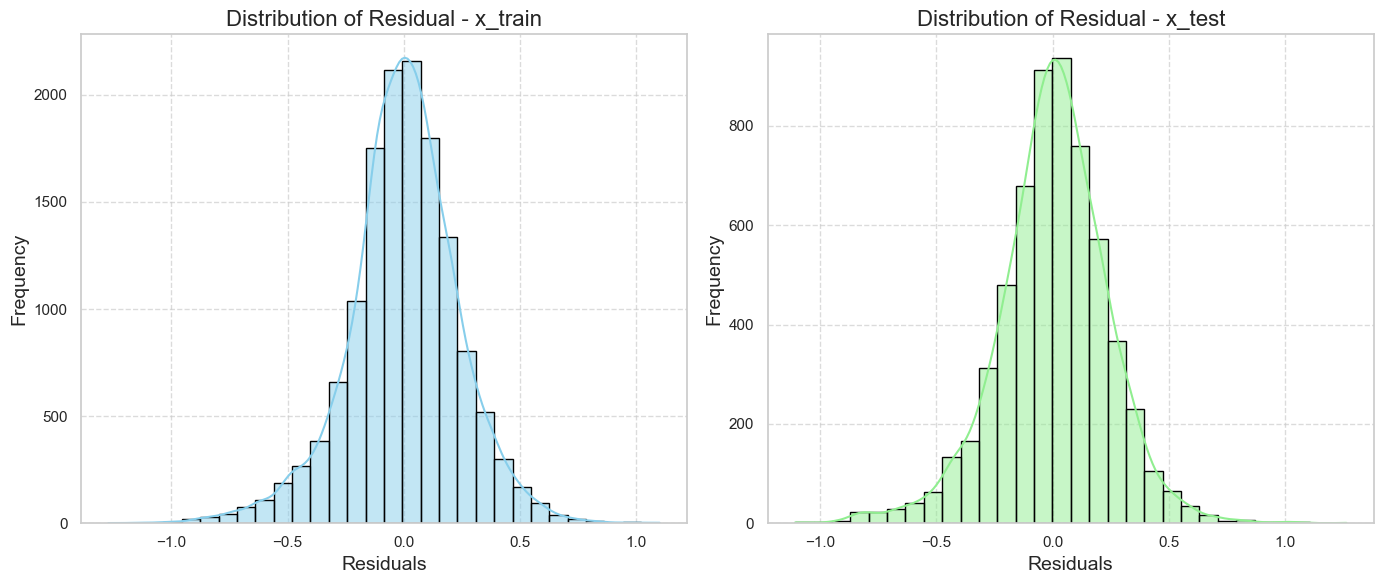

In [43]:
sns.set(style="whitegrid")
plt.figure(figsize=(14, 6))

# Plot residual for x_train
plt.subplot(1, 2, 1)
sns.histplot(y_train - train_prediction, kde=True, color='skyblue', bins=30, edgecolor='black')
plt.title('Distribution of Residual - x_train', fontsize=16)
plt.xlabel('Residuals', fontsize=14)
plt.ylabel('Frequency', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.7)

# Plot residual for x_test
plt.subplot(1, 2, 2)
sns.histplot(y_test - test_prediction, kde=True, color='lightgreen', bins=30, edgecolor='black')
plt.title('Distribution of Residual - x_test', fontsize=16)
plt.xlabel('Residuals', fontsize=14)
plt.ylabel('Frequency', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

We can observe that for both the training and testing sets, the distribution of the residuals—i.e., the difference between the predicted and actual house prices—follows a low-variance distribution centered around zero. This indicates that our linear model has successfully captured the linear relationship between the house prices and the selected features, suggesting that the model performs well. The residuals' behavior further confirms that the model has not only learned the underlying patterns in the data but also generalizes well to unseen data, as demonstrated by the minimal discrepancies between the predicted and actual values. Overall, this reflects the model's robustness and effectiveness in fitting the given dataset.

### P-values
The **p-value** in linear regression tests the null hypothesis that a feature has no effect on the target variable (e.g., house price). A low p-value (typically < 0.05) indicates that the feature significantly contributes to the model, while a high p-value suggests the feature may not be important. 

The p-value is calculated using statistical tests like the F-test, which compares the model with and without the feature. A small p-value means we reject the null hypothesis, suggesting the feature is relevant.

In [44]:
p_values = f_regression(x_train,y_train)[1]
p_values

array([2.21114996e-269, 0.00000000e+000, 0.00000000e+000, 6.45125410e-102,
       1.29975791e-005, 2.70185613e-146, 1.54972634e-009, 0.00000000e+000,
       1.78719888e-021, 6.63928095e-154, 2.56748433e-001, 5.18994337e-003,
       1.02573780e-002, 7.94439323e-002, 2.09427143e-028, 6.11815476e-001,
       1.05512079e-133, 5.90711256e-036, 1.76381358e-001, 3.64220292e-174,
       1.65161703e-027, 4.39468734e-022, 2.83785319e-004, 4.90089872e-054,
       3.58258855e-002, 8.50288812e-084, 2.43187059e-040, 8.03513132e-107,
       2.80756753e-003, 2.45162687e-004, 8.95196035e-001, 2.13023120e-025])

In [45]:
reg_summary = pd.DataFrame(x_train.columns.values, columns=['Features'])
reg_summary['Weights'] = linear_regression.coef_
reg_summary['p-values']=p_values
reg_summary

,Features,Weights,p-values
0,bedrooms,-0.036201,2.211150e-269
1,bathrooms,0.081719,0.000000e+00
2,log_sqft_living,0.404854,0.000000e+00
3,dummy_basement,-0.011702,6.451254e-102
4,condition,0.048351,1.299758e-05
5,view,0.046702,2.701856e-146
6,waterfront,0.232857,1.549726e-09
7,grade,0.161602,0.000000e+00
8,building_age,0.002871,1.787199e-21
9,Bellevue,0.656282,6.639281e-154


We can see that most coefficients are positive and only two of them are negative. If the features' coefficients are positive that means the features can positively affect housing price. However, there is more important sector we need to know which is called p-value. P-value is part of statistical analysis using hypothesis test. If p-values smaller and equal to 0.05, then the features will significantly affect the independent variables, and we can see all features' p-values are significantly smaller than 0.05.

After obtained the predicted values, the first thing we need to do is to see the distribution of our residuals. The images below are the residuals of train and test datasets. Also we can take a look at the results - to see how good our model is - if the scatter plot for actual values and predicted values shows 45 degree trend, that means our model is good enough, because 45 degree means the slope is 1 which implies that our predicted values converge to actual values.

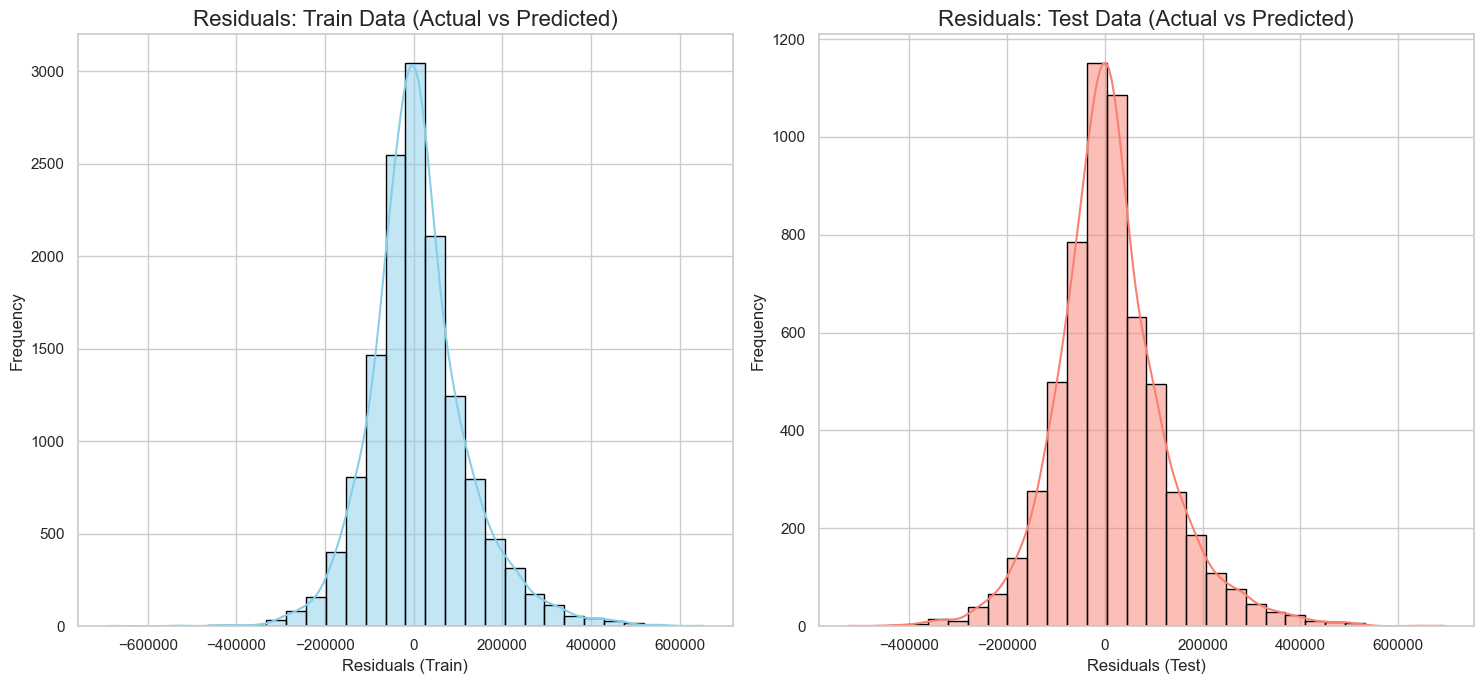

In [46]:
# Reverse the log transformation using np.exp for both train and test data
train_actual = np.exp(y_train)
train_predicted = np.exp(train_prediction)

test_actual = np.exp(y_test)
test_predicted = np.exp(test_prediction)

sns.set(style="whitegrid")
plt.figure(figsize=(15, 7))

# Train data residuals
plt.subplot(1, 2, 1)
sns.histplot(train_actual - train_predicted, kde=True, color='skyblue', bins=30, edgecolor='black')
plt.title("Residuals: Train Data (Actual vs Predicted)", fontsize=16)
plt.xlabel("Residuals (Train)", fontsize=12)
plt.ylabel("Frequency", fontsize=12)

# Test data residuals
plt.subplot(1, 2, 2)
sns.histplot(test_actual - test_predicted, kde=True, color='salmon', bins=30, edgecolor='black')
plt.title("Residuals: Test Data (Actual vs Predicted)", fontsize=16)
plt.xlabel("Residuals (Test)", fontsize=12)
plt.ylabel("Frequency", fontsize=12)

plt.tight_layout()
plt.show()

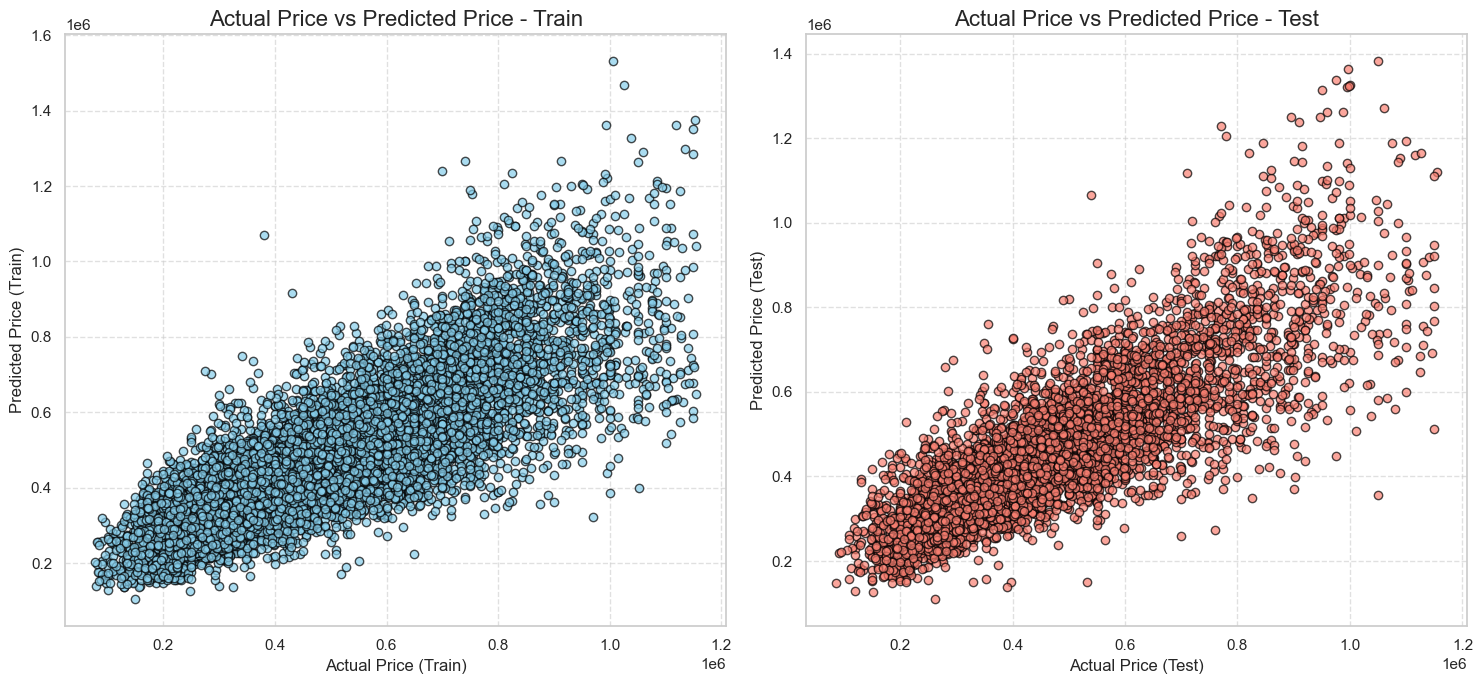

In [47]:
plt.figure(figsize=(15, 7))

# Train data: Actual vs. Predicted prices
plt.subplot(1, 2, 1)
plt.scatter(np.exp(y_train), np.exp(train_prediction), color='skyblue', edgecolor='black', alpha=0.7)
plt.title('Actual Price vs Predicted Price - Train', fontsize=16)
plt.xlabel('Actual Price (Train)', fontsize=12)
plt.ylabel('Predicted Price (Train)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)

# Test data: Actual vs. Predicted prices
plt.subplot(1, 2, 2)
plt.scatter(np.exp(y_test), np.exp(test_prediction), color='salmon', edgecolor='black', alpha=0.7)
plt.title('Actual Price vs Predicted Price - Test', fontsize=16)
plt.xlabel('Actual Price (Test)', fontsize=12)
plt.ylabel('Predicted Price (Test)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

## Room Count Trends

In this section, we analyze the trend of housing prices in relation to room count over the course of a year. Although there are some fluctuations, the overall price trend remains stable. This suggests that room count does not significantly impact price in the short term. While there are periods of price volatility, the influence of room count remains consistent, indicating that other factors likely drive short-term price variations.

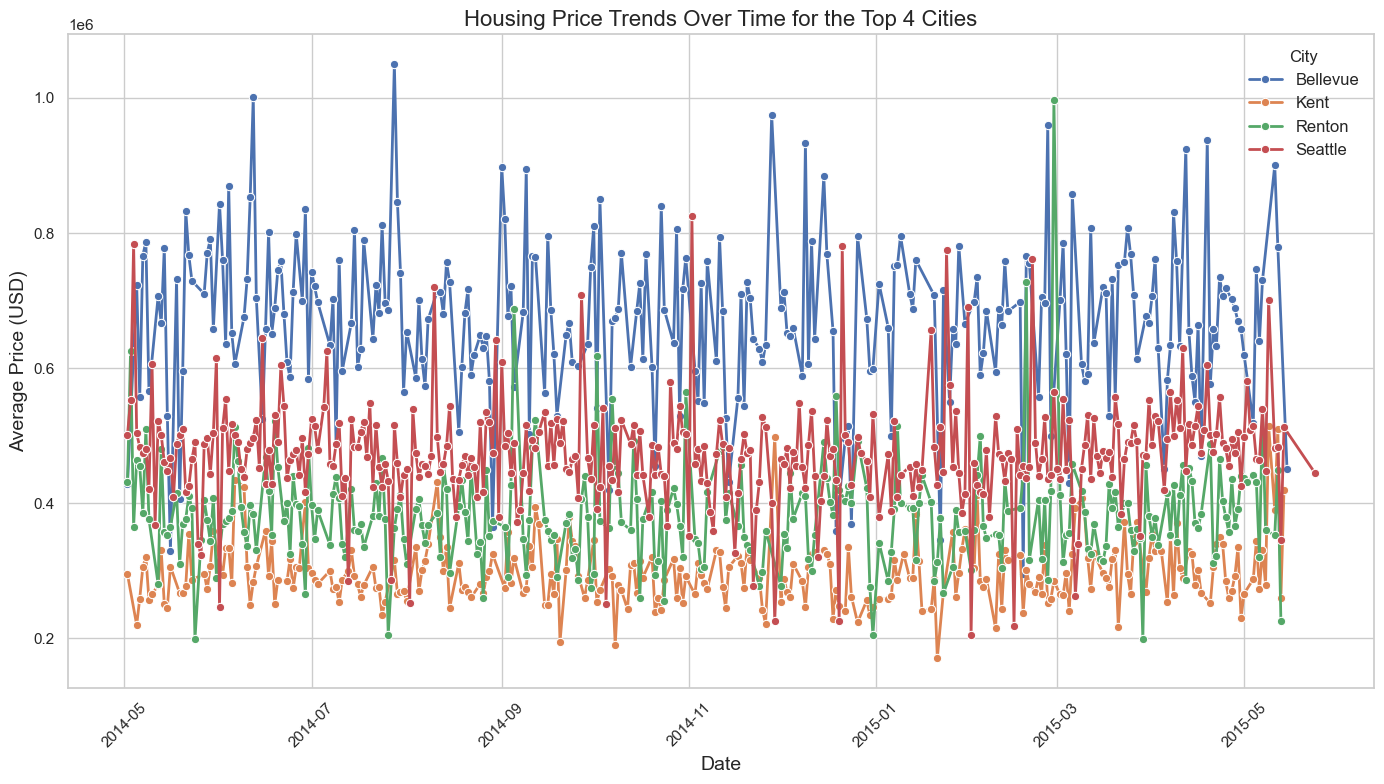

In [51]:
# Calculate the number of houses per city
city_house_count = df_or.groupby('city').size()

# Get the top 4 cities with the most houses
top_cities = city_house_count.nlargest(4).index

# Filter the dataset to only include the top 4 cities
df_top_cities = df_or[df_or['city'].isin(top_cities)]

# Ensure 'date' is in datetime format
df_top_cities['date'] = pd.to_datetime(df_top_cities['date'])

# Group by 'city' and 'date', and calculate the mean price for each group
city_price_time_series = df_top_cities.groupby(['city', 'date'])['price'].mean().reset_index()

# Set up the plot
plt.figure(figsize=(14, 8))

# Plot the price trends over time for each of the top 4 cities with smoothing
sns.lineplot(x='date', y='price', hue='city', data=city_price_time_series, marker='o', lw=2)

# Customize the plot with title and labels
plt.title('Housing Price Trends Over Time for the Top 4 Cities', fontsize=16)
plt.xlabel('Date', fontsize=14)
plt.ylabel('Average Price (USD)', fontsize=14)
plt.xticks(rotation=45)  # Rotate x-axis labels for better readability
plt.legend(title='City', fontsize=12)

# Use a tighter layout to avoid overlapping
plt.tight_layout()

# Show the plot
plt.show()

## Case Study On Seattle


In [52]:

# Filter for one city on 'Seattle'
city_df = df_or[df_or['city'] == 'Seattle']

### Create Interaction Terms

In [ ]:
# Create interaction terms between size (sqft_living) and condition
city_df['size_condition_interaction'] = city_df['sqft_living'] * city_df['condition']

# Alternatively, create polynomial features
poly = PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)
poly_features = poly.fit_transform(city_df[['sqft_living', 'condition']])

# Add these polynomial features to the dataframe
poly_feature_names = poly.get_feature_names_out(['sqft_living', 'condition'])
poly_df = pd.DataFrame(poly_features, columns=poly_feature_names)
city_df = pd.concat([city_df, poly_df], axis=1)

### Run Multiple Linear Regression with Interaction Terms

In [ ]:
city_df = city_df.dropna(subset=['sqft_living', 'condition', 'price'])

# Define the features and target
X = city_df[['sqft_living', 'condition', 'size_condition_interaction']]
y = city_df['price']

# Initialize and fit the model
model = LinearRegression()
model.fit(X, y)

# Print the coefficients
print('Coefficients:', model.coef_)
print('Intercept:', model.intercept_)

Coefficients: [ 1.47819038e+02 -1.37909701e+00  1.90437231e+04 -8.86884808e+02
  1.03634788e+01]
Intercept: 102971.61400989752


### Make Predictions and Visualization

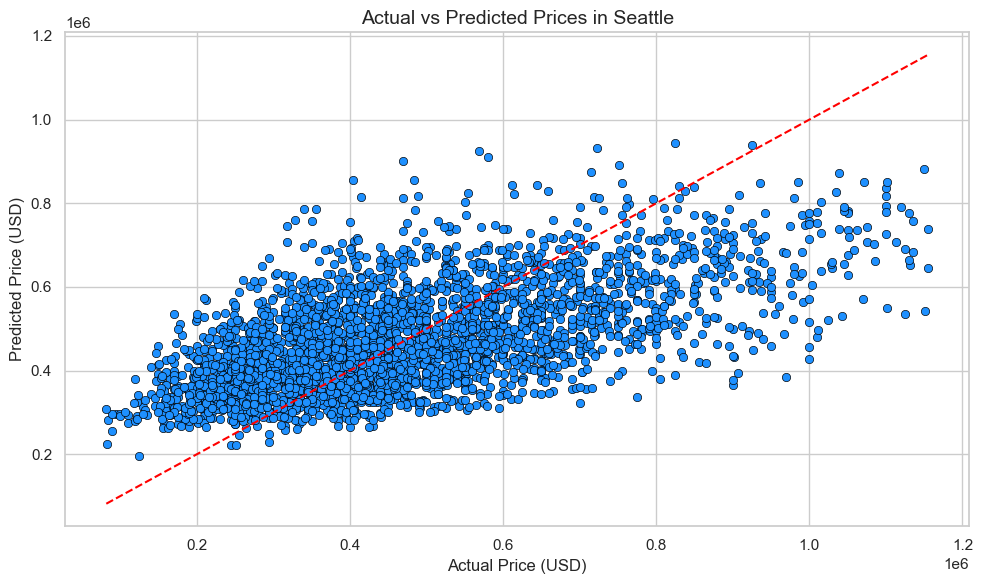

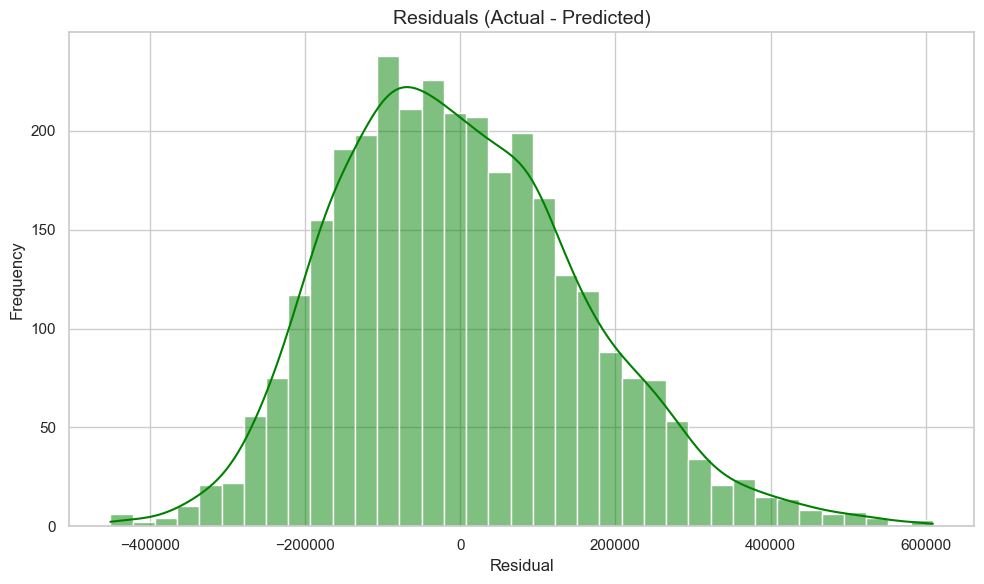

In [62]:
# Predict the prices using the model
city_df['predicted_price'] = model.predict(X)

# Visualize the predicted vs actual prices
plt.figure(figsize=(10, 6))

# Plot actual vs predicted prices
sns.scatterplot(x=city_df['price'], y=city_df['predicted_price'], color='dodgerblue', edgecolor='black')
plt.plot([city_df['price'].min(), city_df['price'].max()], [city_df['price'].min(), city_df['price'].max()], color='red', linestyle='--')  # 45-degree line
plt.title('Actual vs Predicted Prices in Seattle', fontsize=14)
plt.xlabel('Actual Price (USD)', fontsize=12)
plt.ylabel('Predicted Price (USD)', fontsize=12)
plt.tight_layout()
plt.show()

# Plot the residuals (Actual - Predicted)
plt.figure(figsize=(10, 6))
sns.histplot(city_df['price'] - city_df['predicted_price'], kde=True, color='green')
plt.title('Residuals (Actual - Predicted)', fontsize=14)
plt.xlabel('Residual', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.tight_layout()
plt.show()

### **Key Insights**
- **Key Factors Influencing Price**: Square footage, number of bedrooms, and property condition are the most significant determinants of housing prices. Larger homes with more rooms and better conditions generally have higher market value.
- **High-Value Properties**: Homes priced over $650K are heavily influenced by square footage, property condition, and location-specific features like waterfront views. These factors significantly increase perceived value in premium properties.
- **Model Performance**: The multiple linear regression model performed well, achieving a high R² value, indicating that the model explains most of the variance in housing prices. Key features such as square footage, condition, and bedrooms showed strong statistical significance in predicting prices.

### **Recommendations**
1. **Pricing Strategy**: Real estate professionals should focus on larger, well-maintained homes with desirable features like waterfront views. Pricing should reflect the importance of these features, especially for higher-value properties.
2. **Targeted Marketing**: Market larger homes to families or individuals seeking more space. For high-value properties, highlight location-specific features (e.g., waterfront views) to attract premium buyers.
3. **Model Enhancement**: Refine the model by exploring feature interactions and using advanced techniques like Ridge or Lasso regression. Incorporating additional external factors, such as economic indicators, can further improve predictions.

### **Implementation**
Real estate agents can leverage these insights to set competitive yet profitable prices, targeting the right buyers through focused marketing. By continuously refining the model and incorporating external data, they can improve price accuracy and stay ahead of market trends.